# NHANES Mortality × Liver Fibrosis — Analysis

Comparison of all-cause and cause-group death rates within up to 36 months of baseline
among adults **with vs without baseline liver fibrosis**, using public-use NHANES linked
mortality data across three cohorts (2007-2008, 2011-2012, 2017-2018).

**Fibrosis definitions:**
- FIB-4 index (all cohorts): `(age × AST) / (platelets × √ALT)`
- Liver stiffness measurement via transient elastography (2017-2018 only)

**Progressive matching strategy:** Rather than a single propensity-score match on all
covariates at once, we incrementally add metabolic risk factors to the matching model.
This reveals which confounders most attenuate the fibrosis–mortality association and
avoids restricting the sample to the fasting subsample until the final step.

| Step | Covariates matched | Sample restriction |
|------|-------------------|--------------------|
| 0 | *(none — crude)* | Full cohort |
| 1 | Age, Sex | Full cohort |
| 2 | + BMI | Full cohort |
| 3 | + SBP | Full cohort |
| 4 | + Smoking | Full cohort |
| 5 | + LDL-C, FPG | Fasting subsample (~⅓) |

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from IPython.display import Markdown, display

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (9, 5)
sns.set_style('whitegrid')

## Configuration

In [2]:
DERIVED = os.path.join(os.path.abspath('.'), 'data', 'derived')

COHORT_META = {
    '2007-2008': {'has_elast': False},
    '2011-2012': {'has_elast': False},
    '2017-2018': {'has_elast': True},
}

WINDOW_36 = 36
WINDOW_H  = 24  # harmonized window across all cohorts

FIB4_HIGH = 2.67
FIB4_LOW  = 1.30

LSM_CUTPOINTS_A = {'name': 'Castera/EASL', 'sig': 7.1, 'adv': 9.5, 'cir': 12.5}
LSM_CUTPOINTS_B = {'name': 'Eddowes/NAFLD', 'sig': 8.2, 'adv': 9.7, 'cir': 13.6}

UCOD_LABELS = {
    1: 'Heart disease', 2: 'Malignant neoplasms', 3: 'Chronic lower resp.',
    4: 'Accidents', 5: 'Cerebrovascular', 6: "Alzheimer's", 7: 'Diabetes',
    8: 'Influenza/pneumonia', 9: 'Nephritis', 10: 'All other causes',
}

# Progressive matching steps
MATCH_STEPS = [
    {'label': 'Step 1: Demographics',       'covariates': ['AGE', 'FEMALE']},
    {'label': 'Step 2: + BMI',              'covariates': ['AGE', 'FEMALE', 'BMXBMI']},
    {'label': 'Step 3: + SBP',              'covariates': ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN']},
    {'label': 'Step 4: + Smoking',          'covariates': ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN', 'SMOKE_EVER']},
    {'label': 'Step 5: + LDL-C, FPG',       'covariates': ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN', 'SMOKE_EVER', 'LBDLDL', 'LBXGLU']},
]

## Load data

In [3]:
cohorts = {}
for cycle in COHORT_META:
    path = os.path.join(DERIVED, f'{cycle.replace("-","_")}.parquet')
    cohorts[cycle] = pd.read_parquet(path)
    print(f'{cycle}: {len(cohorts[cycle]):,} rows')

2007-2008: 6,219 rows
2011-2012: 5,849 rows
2017-2018: 5,809 rows


## Define fibrosis status

In [4]:
def compute_fib4(df):
    df = df.copy()
    ok = (df['AST']>0) & (df['ALT']>0) & (df['PLATELETS']>0) & df['AGE'].notna()
    df['FIB4'] = np.nan
    df.loc[ok,'FIB4'] = (df.loc[ok,'AGE']*df.loc[ok,'AST']) / (
        df.loc[ok,'PLATELETS']*np.sqrt(df.loc[ok,'ALT']))
    
    df['FIB4_CAT'] = pd.Series(np.nan, index=df.index, dtype='object')
    df.loc[df['FIB4'] < FIB4_LOW,  'FIB4_CAT'] = 'low'
    df.loc[(df['FIB4']>=FIB4_LOW) & (df['FIB4']<FIB4_HIGH), 'FIB4_CAT'] = 'indeterminate'
    df.loc[df['FIB4']>=FIB4_HIGH, 'FIB4_CAT'] = 'high'
    
    df['FIBROSIS_FIB4'] = np.nan
    df.loc[df['FIB4_CAT']=='high', 'FIBROSIS_FIB4'] = 1
    df.loc[df['FIB4_CAT']=='low',  'FIBROSIS_FIB4'] = 0
    return df

def compute_lsm(df, cp):
    df = df.copy()
    pfx = cp['name'].replace('/','_').replace(' ','_')
    col_s, col_b = f'LSM_STAGE_{pfx}', f'FIBROSIS_LSM_{pfx}'
    df[col_s] = pd.Series(np.nan, index=df.index, dtype='object')
    df[col_b] = np.nan
    if 'LSM_KPA' not in df.columns: return df
    ok = df['LSM_KPA'].notna()
    df.loc[ok & (df['LSM_KPA']<cp['sig']),  col_s] = 'F0-F1'
    df.loc[ok & (df['LSM_KPA']>=cp['sig']) & (df['LSM_KPA']<cp['adv']), col_s] = 'F2'
    df.loc[ok & (df['LSM_KPA']>=cp['adv']) & (df['LSM_KPA']<cp['cir']), col_s] = 'F3'
    df.loc[ok & (df['LSM_KPA']>=cp['cir']), col_s] = 'F4'
    df.loc[df[col_s].isin(['F3','F4']), col_b] = 1
    df.loc[df[col_s]=='F0-F1', col_b] = 0
    return df

for cycle in cohorts:
    cohorts[cycle] = compute_fib4(cohorts[cycle])
    if COHORT_META[cycle]['has_elast']:
        cohorts[cycle] = compute_lsm(cohorts[cycle], LSM_CUTPOINTS_A)
        cohorts[cycle] = compute_lsm(cohorts[cycle], LSM_CUTPOINTS_B)

for cycle, df in cohorts.items():
    vc = df['FIB4_CAT'].value_counts()
    print(f'\n{cycle} FIB-4: {vc.to_dict()}, missing={df["FIB4"].isna().sum()}')
    if COHORT_META[cycle]['has_elast']:
        for cp in [LSM_CUTPOINTS_A, LSM_CUTPOINTS_B]:
            pfx = cp['name'].replace('/','_').replace(' ','_')
            col = f'FIBROSIS_LSM_{pfx}'
            print(f"  LSM {cp['name']}: fib+={int((df[col]==1).sum())}, fib-={int((df[col]==0).sum())}")


2007-2008 FIB-4: {'low': 3982, 'indeterminate': 1391, 'high': 172}, missing=674

2011-2012 FIB-4: {'low': 3523, 'indeterminate': 1399, 'high': 215}, missing=712

2017-2018 FIB-4: {'low': 3573, 'indeterminate': 1342, 'high': 189}, missing=705
  LSM Castera/EASL: fib+=386, fib-=4274
  LSM Eddowes/NAFLD: fib+=370, fib-=4536


## Define outcomes

In [5]:
def add_outcomes(df, window):
    w = f'_{window}m'
    df[f'FU{w}']      = df['PERMTH_EXM'].clip(upper=window)
    df[f'PY{w}']      = df[f'FU{w}'] / 12.0
    df[f'DEATH{w}']   = ((df['MORTSTAT']==1) & (df['PERMTH_EXM']<=window)).astype(int)
    for code in UCOD_LABELS:
        df[f'D_UCOD{code}{w}'] = ((df[f'DEATH{w}']==1) & (df['UCOD_LEADING']==code)).astype(int)
    return df

for cycle, df in cohorts.items():
    df = add_outcomes(df, WINDOW_H)
    if cycle != '2017-2018':
        df = add_outcomes(df, WINDOW_36)
    cohorts[cycle] = df

for cycle, df in cohorts.items():
    d24 = df['DEATH_24m'].sum()
    pct = (df['PERMTH_EXM']>=24).mean()*100
    msg = f'{cycle}: {len(df):,} adults, {d24} deaths in 24m, {pct:.0f}% with >=24m FU'
    if cycle != '2017-2018':
        d36 = df['DEATH_36m'].sum()
        msg += f', {d36} deaths in 36m'
    print(msg)

2007-2008: 6,219 adults, 151 deaths in 24m, 94% with >=24m FU, 236 deaths in 36m
2011-2012: 5,849 adults, 111 deaths in 24m, 94% with >=24m FU, 180 deaths in 36m
2017-2018: 5,809 adults, 113 deaths in 24m, 48% with >=24m FU


## Cohort descriptive cards

In [6]:
cards = []
for cycle, df in cohorts.items():
    for window in ([WINDOW_H, WINDOW_36] if cycle != '2017-2018' else [WINDOW_H]):
        w = f'_{window}m'
        iqr = df['PERMTH_EXM'].quantile([.25,.75])
        row = {
            'Cycle': cycle, 'Window (m)': window,
            'N adults': len(df),
            'N FIB4 valid': int(df['FIB4'].notna().sum()),
            'FIB4 high': int((df['FIB4_CAT']=='high').sum()),
            'FIB4 low': int((df['FIB4_CAT']=='low').sum()),
            'FIB4 indet': int((df['FIB4_CAT']=='indeterminate').sum()),
            'N with LSM': int(df['LSM_KPA'].notna().sum()) if 'LSM_KPA' in df.columns else 0,
            'Median FU (m)': df['PERMTH_EXM'].median(),
            'IQR FU': f"{iqr.iloc[0]:.0f}\u2013{iqr.iloc[1]:.0f}",
            '% >= window': f"{(df['PERMTH_EXM']>=window).mean()*100:.1f}",
            'Deaths': int(df[f'DEATH{w}'].sum()),
        }
        cards.append(row)

cards_df = pd.DataFrame(cards)
cards_df

,Cycle,Window (m),N adults,N FIB4 valid,FIB4 high,FIB4 low,FIB4 indet,N with LSM,Median FU (m),IQR FU,% >= window,Deaths
0,2007-2008,24,6219,5545,172,3982,1391,0,141.0,134–148,93.9,151
1,2007-2008,36,6219,5545,172,3982,1391,0,141.0,134–148,92.7,236
2,2011-2012,24,5849,5137,215,3523,1399,0,94.0,89–101,93.9,111
3,2011-2012,36,5849,5137,215,3523,1399,0,94.0,89–101,92.8,180
4,2017-2018,24,5809,5104,189,3573,1342,5091,24.0,17–30,48.2,113


## Unmatched death rates by fibrosis status

In [7]:
def rate_table(df, fib_col, fib_label, window, cycle):
    w = f'_{window}m'
    rows = []
    for val, name in [(1,'Fibrosis+'),(0,'Fibrosis-')]:
        s = df[df[fib_col]==val]
        n = len(s)
        if n == 0: continue
        d = s[f'DEATH{w}'].sum()
        py = s[f'PY{w}'].sum()
        row = {'Cycle':cycle, 'Window':window, 'Def':fib_label,
               'Group':name, 'N':n, 'Deaths':int(d),
               'PY':round(py,1),
               'Risk':round(d/n,4) if n else np.nan,
               'Rate/1000PY':round(d/py*1000,1) if py>0 else np.nan}
        for code, lab in UCOD_LABELS.items():
            dc = s[f'D_UCOD{code}{w}'].sum()
            row[f'd_{lab}'] = int(dc)
        rows.append(row)
    return pd.DataFrame(rows)

all_rates = []
for cycle, df in cohorts.items():
    windows = [WINDOW_H] + ([WINDOW_36] if cycle != '2017-2018' else [])
    fib_defs = [('FIB4 \u22652.67 vs <1.30', 'FIBROSIS_FIB4')]
    if COHORT_META[cycle]['has_elast']:
        for cp in [LSM_CUTPOINTS_A, LSM_CUTPOINTS_B]:
            pfx = cp['name'].replace('/','_').replace(' ','_')
            fib_defs.append((f"LSM {cp['name']}", f'FIBROSIS_LSM_{pfx}'))
    for w in windows:
        for lab, col in fib_defs:
            all_rates.append(rate_table(df, col, lab, w, cycle))

rates_df = pd.concat(all_rates, ignore_index=True)
rates_df[['Cycle','Window','Def','Group','N','Deaths','PY','Risk','Rate/1000PY']]

,Cycle,Window,Def,Group,N,Deaths,PY,Risk,Rate/1000PY
0,2007-2008,24,FIB4 ≥2.67 vs <1.30,Fibrosis+,172,22,322.2,0.1279,68.3
1,2007-2008,24,FIB4 ≥2.67 vs <1.30,Fibrosis-,3982,39,7928.4,0.0098,4.9
2,2007-2008,36,FIB4 ≥2.67 vs <1.30,Fibrosis+,172,31,469.0,0.1802,66.1
3,2007-2008,36,FIB4 ≥2.67 vs <1.30,Fibrosis-,3982,56,11861.6,0.0141,4.7
4,2011-2012,24,FIB4 ≥2.67 vs <1.30,Fibrosis+,215,23,406.9,0.1070,56.5
5,2011-2012,24,FIB4 ≥2.67 vs <1.30,Fibrosis-,3523,19,7029.8,0.0054,2.7
6,2011-2012,36,FIB4 ≥2.67 vs <1.30,Fibrosis+,215,36,593.1,0.1674,60.7
7,2011-2012,36,FIB4 ≥2.67 vs <1.30,Fibrosis-,3523,38,10525.7,0.0108,3.6
8,2017-2018,24,FIB4 ≥2.67 vs <1.30,Fibrosis+,189,26,300.2,0.1376,86.6
9,2017-2018,24,FIB4 ≥2.67 vs <1.30,Fibrosis-,3573,20,6195.7,0.0056,3.2


## Progressive propensity-score matching

At each step we add covariates to the PS model, re-match, and measure the fibrosis–mortality
association. This shows how the risk ratio attenuates as we progressively balance
confounders between fibrosis+ and fibrosis− groups.

In [8]:
def propensity_match(df, fib_col, covariates, caliper=0.2, random_state=42):
    """
    1:1 nearest-neighbour propensity-score matching without replacement.
    Returns (matched_df, n_treated_available, n_control_available).
    """
    sub = df.dropna(subset=[fib_col] + covariates).copy()
    treated  = sub[sub[fib_col]==1]
    control  = sub[sub[fib_col]==0]
    
    if len(treated) < 5 or len(control) < 5:
        return pd.DataFrame(), len(treated), len(control)
    
    X = sub[covariates].copy()
    for c in covariates:
        if sub[c].nunique() > 2:
            X[c] = (X[c] - X[c].mean()) / (X[c].std() + 1e-8)
    y = sub[fib_col].astype(int)
    
    try:
        model = sm.Logit(y, sm.add_constant(X)).fit(disp=0, maxiter=100)
        sub['ps'] = model.predict(sm.add_constant(X))
    except Exception as e:
        print(f'  PS model failed: {e}')
        return pd.DataFrame(), len(treated), len(control)
    
    ps_std = sub['ps'].std()
    cal = caliper * ps_std
    
    treated_idx = sub[sub[fib_col]==1].index.tolist()
    control_idx = sub[sub[fib_col]==0].index.tolist()
    
    rng = np.random.default_rng(random_state)
    rng.shuffle(treated_idx)
    
    matched_t, matched_c = [], []
    used = set()
    ctrl_ps = sub.loc[control_idx, 'ps'].values
    ctrl_arr = np.array(control_idx)
    
    for t_i in treated_idx:
        ps_t = sub.loc[t_i, 'ps']
        dists = np.abs(ctrl_ps - ps_t)
        mask = np.array([c not in used for c in ctrl_arr])
        dists[~mask] = np.inf
        best = np.argmin(dists)
        if dists[best] <= cal:
            c_i = ctrl_arr[best]
            matched_t.append(t_i)
            matched_c.append(c_i)
            used.add(c_i)
    
    if not matched_t:
        return pd.DataFrame(), len(treated), len(control)
    
    match_ids = list(range(len(matched_t)))
    mt = sub.loc[matched_t].copy(); mt['MATCH_ID'] = match_ids
    mc = sub.loc[matched_c].copy(); mc['MATCH_ID'] = match_ids
    matched = pd.concat([mt, mc], ignore_index=True)
    return matched, len(treated), len(control)


def covariate_balance(df, fib_col, covariates):
    rows = []
    for c in covariates:
        t = df.loc[df[fib_col]==1, c].dropna()
        ctrl = df.loc[df[fib_col]==0, c].dropna()
        if len(t)==0 or len(ctrl)==0:
            rows.append({'Covariate':c, 'SMD':np.nan})
            continue
        pooled_std = np.sqrt((t.var() + ctrl.var()) / 2)
        smd = (t.mean() - ctrl.mean()) / pooled_std if pooled_std > 0 else 0
        rows.append({'Covariate':c, 'SMD':round(smd,3)})
    return pd.DataFrame(rows)


def risk_ratio(df, fib_col, window):
    w = f'_{window}m'
    t = df[df[fib_col]==1]; c = df[df[fib_col]==0]
    n1,n0 = len(t),len(c)
    d1 = t[f'DEATH{w}'].sum(); d0 = c[f'DEATH{w}'].sum()
    if n1==0 or n0==0 or d0==0:
        return {'RR':np.nan,'lo':np.nan,'hi':np.nan,'d1':int(d1),'d0':int(d0),'n1':n1,'n0':n0}
    r1,r0 = d1/n1, d0/n0
    rr = r1/r0
    se = np.sqrt(1/d1 - 1/n1 + 1/d0 - 1/n0) if d1>0 else np.nan
    lo = np.exp(np.log(rr)-1.96*se) if np.isfinite(se) else np.nan
    hi = np.exp(np.log(rr)+1.96*se) if np.isfinite(se) else np.nan
    return {'RR':round(rr,2),'lo':round(lo,2),'hi':round(hi,2),
            'd1':int(d1),'d0':int(d0),'n1':n1,'n0':n0}

In [9]:
# Run progressive matching for FIB-4 across all cohorts
prog_results = {}  # (cycle, step_label) -> {'matched': df, 'fib_col': str, 'rr': dict, ...}

for cycle, df in cohorts.items():
    fib_col = 'FIBROSIS_FIB4'
    window = WINDOW_H
    w = f'_{window}m'
    print(f'\n{"="*60}')
    print(f'{cycle}: FIB-4 progressive matching (window={window}m)')
    print(f'{"="*60}')
    
    # Step 0: Crude (unmatched)
    sub0 = df[df[fib_col].notna()].copy()
    rr0 = risk_ratio(sub0, fib_col, window)
    prog_results[(cycle, 'Step 0: Crude')] = {
        'matched': sub0, 'fib_col': fib_col, 'rr': rr0,
        'n_pairs': None, 'covariates': [],
        'n_available_treated': int((sub0[fib_col]==1).sum()),
        'n_available_control': int((sub0[fib_col]==0).sum()),
    }
    print(f'\n  Step 0 (Crude): n+={rr0["n1"]}, n-={rr0["n0"]}, '
          f'd+={rr0["d1"]}, d-={rr0["d0"]}, RR={rr0["RR"]} [{rr0["lo"]}–{rr0["hi"]}]')
    
    # Steps 1-5: progressive matching
    for step in MATCH_STEPS:
        covs = step['covariates']
        label = step['label']
        print(f'\n  {label} — covariates: {covs}')
        
        result = propensity_match(df, fib_col, covs)
        mdf, n_t, n_c = result
        
        if len(mdf) == 0:
            print(f'    No matches found')
            prog_results[(cycle, label)] = {
                'matched': pd.DataFrame(), 'fib_col': fib_col, 'rr': None,
                'n_pairs': 0, 'covariates': covs,
                'n_available_treated': n_t, 'n_available_control': n_c,
            }
            continue
        
        # Add outcomes to matched data
        mdf = add_outcomes(mdf, window)
        if cycle != '2017-2018':
            mdf = add_outcomes(mdf, WINDOW_36)
        
        n_pairs = int((mdf[fib_col]==1).sum())
        rr = risk_ratio(mdf, fib_col, window)
        
        prog_results[(cycle, label)] = {
            'matched': mdf, 'fib_col': fib_col, 'rr': rr,
            'n_pairs': n_pairs, 'covariates': covs,
            'n_available_treated': n_t, 'n_available_control': n_c,
        }
        
        print(f'    Available: treated={n_t}, control={n_c}')
        print(f'    Matched {n_pairs} pairs')
        print(f'    d+={rr["d1"]}, d-={rr["d0"]}, RR={rr["RR"]} [{rr["lo"]}–{rr["hi"]}]')
        
        # Show balance
        all_covs = ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN', 'SMOKE_EVER', 'LBDLDL', 'LBXGLU']
        bal = covariate_balance(mdf, fib_col, all_covs)
        print(f'    Balance (|SMD|): ' + 
              ', '.join(f'{r["Covariate"]}={abs(r["SMD"]):.2f}'
                        for _, r in bal.iterrows() if pd.notna(r['SMD'])))


2007-2008: FIB-4 progressive matching (window=24m)

  Step 0 (Crude): n+=172, n-=3982, d+=22, d-=39, RR=13.06 [7.92–21.53]

  Step 1: Demographics — covariates: ['AGE', 'FEMALE']


    Available: treated=172, control=3982
    Matched 127 pairs
    d+=16, d-=7, RR=2.29 [0.97–5.37]
    Balance (|SMD|): AGE=0.01, FEMALE=0.03, BMXBMI=0.42, SBP_MEAN=0.17, SMOKE_EVER=0.08, LBDLDL=0.54, LBXGLU=0.16

  Step 2: + BMI — covariates: ['AGE', 'FEMALE', 'BMXBMI']
    Available: treated=168, control=3928
    Matched 129 pairs
    d+=13, d-=4, RR=3.25 [1.09–9.7]
    Balance (|SMD|): AGE=0.04, FEMALE=0.06, BMXBMI=0.10, SBP_MEAN=0.05, SMOKE_EVER=0.05, LBDLDL=0.88, LBXGLU=0.17

  Step 3: + SBP — covariates: ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN']
    Available: treated=163, control=3777
    Matched 123 pairs
    d+=13, d-=3, RR=4.33 [1.27–14.83]
    Balance (|SMD|): AGE=0.01, FEMALE=0.08, BMXBMI=0.08, SBP_MEAN=0.01, SMOKE_EVER=0.02, LBDLDL=0.77, LBXGLU=0.27

  Step 4: + Smoking — covariates: ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN', 'SMOKE_EVER']


    Available: treated=163, control=3542
    Matched 123 pairs
    d+=13, d-=4, RR=3.25 [1.09–9.69]
    Balance (|SMD|): AGE=0.02, FEMALE=0.02, BMXBMI=0.02, SBP_MEAN=0.05, SMOKE_EVER=0.00, LBDLDL=0.62, LBXGLU=0.04

  Step 5: + LDL-C, FPG — covariates: ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN', 'SMOKE_EVER', 'LBDLDL', 'LBXGLU']
    Available: treated=79, control=1663
    Matched 59 pairs
    d+=6, d-=1, RR=6.0 [0.75–48.32]
    Balance (|SMD|): AGE=0.02, FEMALE=0.20, BMXBMI=0.01, SBP_MEAN=0.24, SMOKE_EVER=0.20, LBDLDL=0.02, LBXGLU=0.16

2011-2012: FIB-4 progressive matching (window=24m)

  Step 0 (Crude): n+=215, n-=3523, d+=23, d-=19, RR=19.84 [10.98–35.85]

  Step 1: Demographics — covariates: ['AGE', 'FEMALE']
    Available: treated=215, control=3523
    Matched 120 pairs
    d+=8, d-=5, RR=1.6 [0.54–4.75]
    Balance (|SMD|): AGE=0.01, FEMALE=0.02, BMXBMI=0.17, SBP_MEAN=0.09, SMOKE_EVER=0.08, LBDLDL=0.34, LBXGLU=0.04

  Step 2: + BMI — covariates: ['AGE', 'FEMALE', 'BMXBMI']


    Available: treated=207, control=3481
    Matched 125 pairs
    d+=8, d-=6, RR=1.33 [0.48–3.73]
    Balance (|SMD|): AGE=0.01, FEMALE=0.06, BMXBMI=0.01, SBP_MEAN=0.02, SMOKE_EVER=0.19, LBDLDL=0.17, LBXGLU=0.08

  Step 3: + SBP — covariates: ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN']
    Available: treated=201, control=3347
    Matched 119 pairs
    d+=7, d-=7, RR=1.0 [0.36–2.76]
    Balance (|SMD|): AGE=0.01, FEMALE=0.05, BMXBMI=0.18, SBP_MEAN=0.11, SMOKE_EVER=0.10, LBDLDL=0.14, LBXGLU=0.02

  Step 4: + Smoking — covariates: ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN', 'SMOKE_EVER']
    Available: treated=201, control=3097
    Matched 118 pairs
    d+=8, d-=7, RR=1.14 [0.43–3.05]
    Balance (|SMD|): AGE=0.00, FEMALE=0.03, BMXBMI=0.04, SBP_MEAN=0.04, SMOKE_EVER=0.03, LBDLDL=0.30, LBXGLU=0.02

  Step 5: + LDL-C, FPG — covariates: ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN', 'SMOKE_EVER', 'LBDLDL', 'LBXGLU']


    Available: treated=100, control=1480
    Matched 65 pairs
    d+=3, d-=2, RR=1.5 [0.26–8.68]
    Balance (|SMD|): AGE=0.01, FEMALE=0.06, BMXBMI=0.04, SBP_MEAN=0.13, SMOKE_EVER=0.06, LBDLDL=0.04, LBXGLU=0.08

2017-2018: FIB-4 progressive matching (window=24m)

  Step 0 (Crude): n+=189, n-=3573, d+=26, d-=20, RR=24.58 [13.98–43.21]

  Step 1: Demographics — covariates: ['AGE', 'FEMALE']
    Available: treated=189, control=3573
    Matched 152 pairs
    d+=20, d-=4, RR=5.0 [1.75–14.28]
    Balance (|SMD|): AGE=0.01, FEMALE=0.08, BMXBMI=0.28, SBP_MEAN=0.05, SMOKE_EVER=0.03, LBDLDL=0.17, LBXGLU=0.17

  Step 2: + BMI — covariates: ['AGE', 'FEMALE', 'BMXBMI']
    Available: treated=181, control=3534
    Matched 141 pairs
    d+=16, d-=3, RR=5.33 [1.59–17.9]
    Balance (|SMD|): AGE=0.01, FEMALE=0.04, BMXBMI=0.01, SBP_MEAN=0.23, SMOKE_EVER=0.01, LBDLDL=0.12, LBXGLU=0.08

  Step 3: + SBP — covariates: ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN']


    Available: treated=174, control=3390
    Matched 133 pairs
    d+=13, d-=2, RR=6.5 [1.5–28.25]
    Balance (|SMD|): AGE=0.04, FEMALE=0.08, BMXBMI=0.13, SBP_MEAN=0.02, SMOKE_EVER=0.01, LBDLDL=0.32, LBXGLU=0.13

  Step 4: + Smoking — covariates: ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN', 'SMOKE_EVER']
    Available: treated=174, control=3390
    Matched 135 pairs
    d+=13, d-=2, RR=6.5 [1.5–28.26]
    Balance (|SMD|): AGE=0.05, FEMALE=0.10, BMXBMI=0.14, SBP_MEAN=0.07, SMOKE_EVER=0.07, LBDLDL=0.14, LBXGLU=0.03

  Step 5: + LDL-C, FPG — covariates: ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN', 'SMOKE_EVER', 'LBDLDL', 'LBXGLU']
    Available: treated=87, control=1589
    Matched 77 pairs
    d+=7, d-=2, RR=3.5 [0.75–16.32]
    Balance (|SMD|): AGE=0.04, FEMALE=0.05, BMXBMI=0.00, SBP_MEAN=0.03, SMOKE_EVER=0.05, LBDLDL=0.13, LBXGLU=0.01


### Progressive matching summary table

In [10]:
summary_rows = []
for (cycle, label), res in prog_results.items():
    rr = res['rr']
    row = {
        'Cycle': cycle,
        'Step': label,
        'Covariates': ', '.join(res['covariates']) if res['covariates'] else '(none)',
        'N+ available': res['n_available_treated'],
        'N- available': res['n_available_control'],
        'N matched pairs': res['n_pairs'] if res['n_pairs'] is not None else f"{res['n_available_treated']} vs {res['n_available_control']}",
    }
    if rr:
        row['Deaths(Fib+)'] = rr['d1']
        row['Deaths(Fib-)'] = rr['d0']
        row['RR'] = rr['RR']
        row['95% CI'] = f"{rr['lo']}\u2013{rr['hi']}" if pd.notna(rr['lo']) else '\u2014'
    else:
        row['Deaths(Fib+)'] = '\u2014'
        row['Deaths(Fib-)'] = '\u2014'
        row['RR'] = '\u2014'
        row['95% CI'] = '\u2014'
    summary_rows.append(row)

prog_summary = pd.DataFrame(summary_rows)
prog_summary

,Cycle,Step,Covariates,N+ available,N- available,N matched pairs,Deaths(Fib+),Deaths(Fib-),RR,95% CI
0,2007-2008,Step 0: Crude,(none),172,3982,172 vs 3982,22,39,13.06,7.92–21.53
1,2007-2008,Step 1: Demographics,"AGE, FEMALE",172,3982,127,16,7,2.29,0.97–5.37
2,2007-2008,Step 2: + BMI,"AGE, FEMALE, BMXBMI",168,3928,129,13,4,3.25,1.09–9.7
3,2007-2008,Step 3: + SBP,"AGE, FEMALE, BMXBMI, SBP_MEAN",163,3777,123,13,3,4.33,1.27–14.83
4,2007-2008,Step 4: + Smoking,"AGE, FEMALE, BMXBMI, SBP_MEAN, SMOKE_EVER",163,3542,123,13,4,3.25,1.09–9.69
5,2007-2008,"Step 5: + LDL-C, FPG","AGE, FEMALE, BMXBMI, SBP_MEAN, SMOKE_EVER, LBD...",79,1663,59,6,1,6.00,0.75–48.32
6,2011-2012,Step 0: Crude,(none),215,3523,215 vs 3523,23,19,19.84,10.98–35.85
7,2011-2012,Step 1: Demographics,"AGE, FEMALE",215,3523,120,8,5,1.60,0.54–4.75
8,2011-2012,Step 2: + BMI,"AGE, FEMALE, BMXBMI",207,3481,125,8,6,1.33,0.48–3.73
9,2011-2012,Step 3: + SBP,"AGE, FEMALE, BMXBMI, SBP_MEAN",201,3347,119,7,7,1.00,0.36–2.76


### Forest plot: progressive attenuation of risk ratio

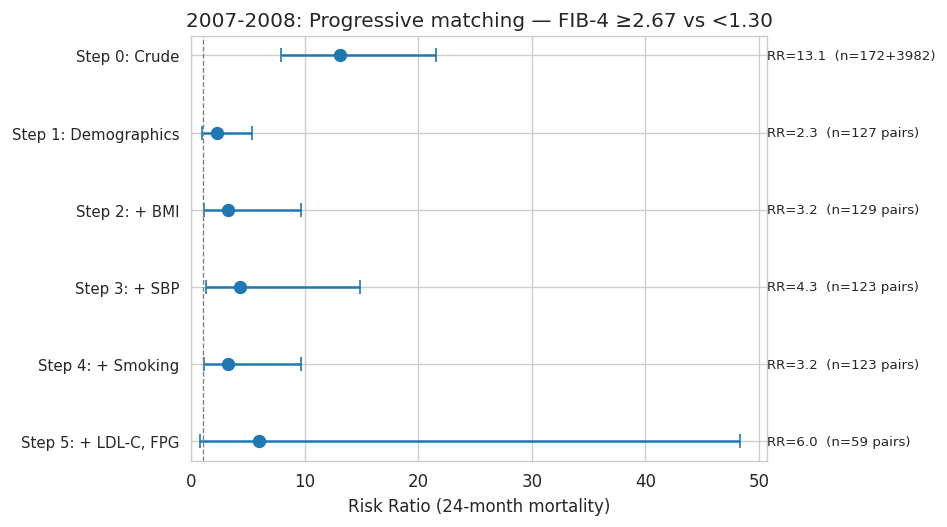

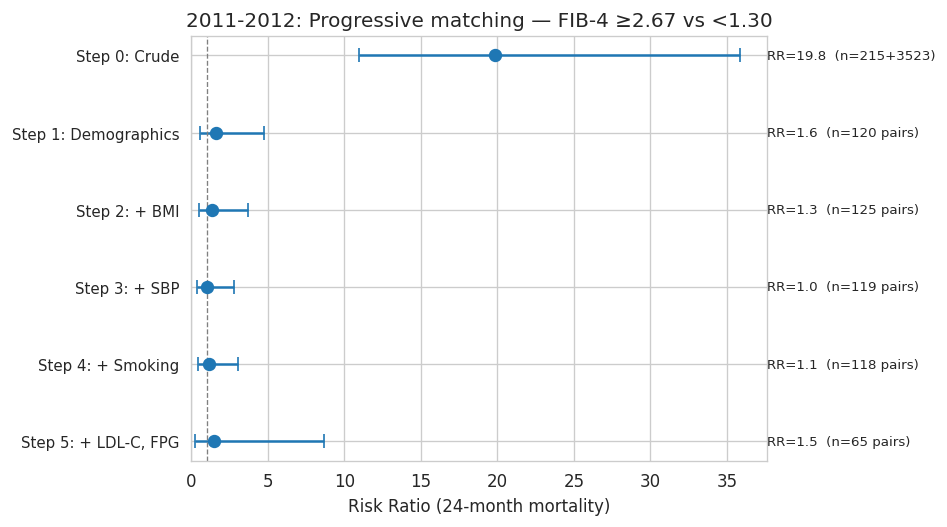

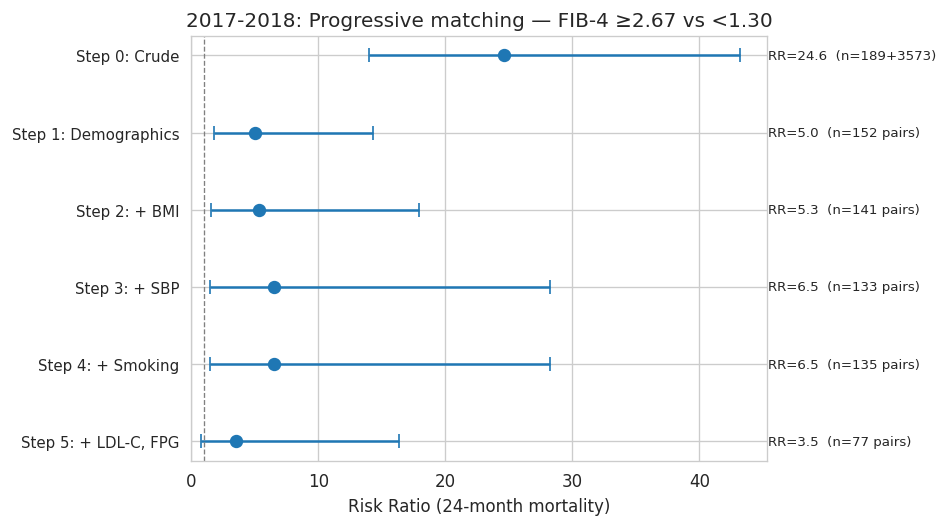

In [11]:
step_order = ['Step 0: Crude'] + [s['label'] for s in MATCH_STEPS]

for cycle in cohorts:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    
    y_labels, rrs, los, his, ns = [], [], [], [], []
    for label in step_order:
        key = (cycle, label)
        if key not in prog_results:
            continue
        res = prog_results[key]
        rr = res['rr']
        if rr is None or pd.isna(rr['RR']):
            continue
        y_labels.append(label)
        rrs.append(rr['RR'])
        los.append(rr['lo'])
        his.append(rr['hi'])
        n = res['n_pairs']
        ns.append(f'n={n} pairs' if n is not None else
                  f"n={res['n_available_treated']}+{res['n_available_control']}")
    
    if not rrs:
        continue
    
    y_pos = np.arange(len(y_labels))
    ax.errorbar(rrs, y_pos, xerr=[np.array(rrs)-np.array(los), np.array(his)-np.array(rrs)],
                fmt='o', color='#1f77b4', capsize=4, markersize=7, lw=1.5)
    ax.axvline(1.0, color='gray', ls='--', lw=0.8)
    
    for i, (rr, n_lab) in enumerate(zip(rrs, ns)):
        ax.text(max(his) * 1.05, i, f'RR={rr:.1f}  ({n_lab})', va='center', fontsize=8)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Risk Ratio (24-month mortality)')
    ax.set_title(f'{cycle}: Progressive matching — FIB-4 \u22652.67 vs <1.30')
    ax.set_xlim(left=0)
    plt.tight_layout()
    plt.show()

### Progressive Love plots: covariate balance at each step

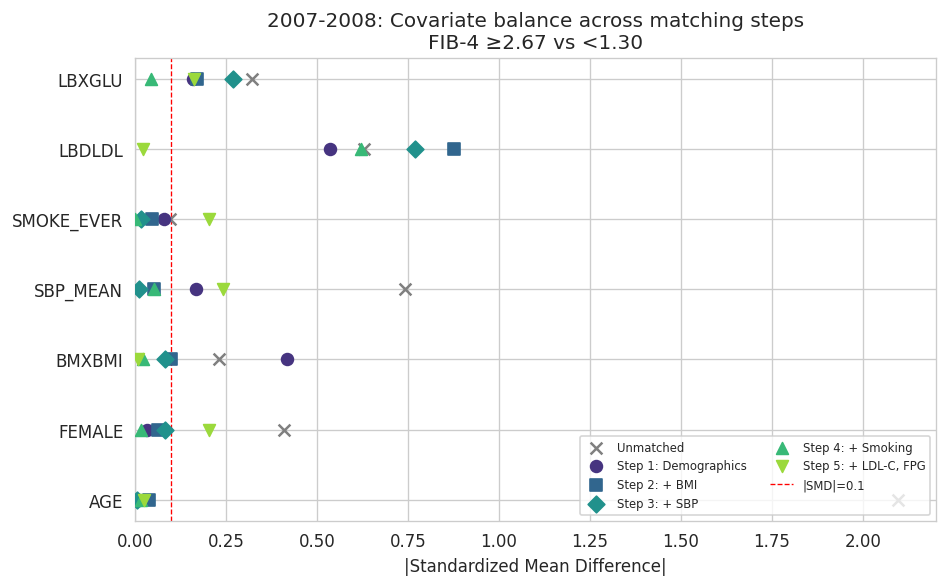

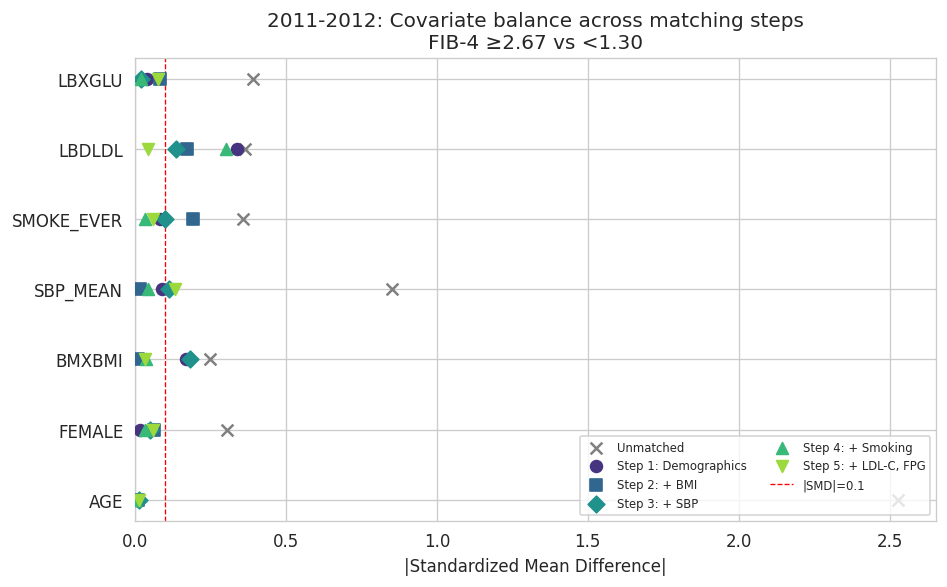

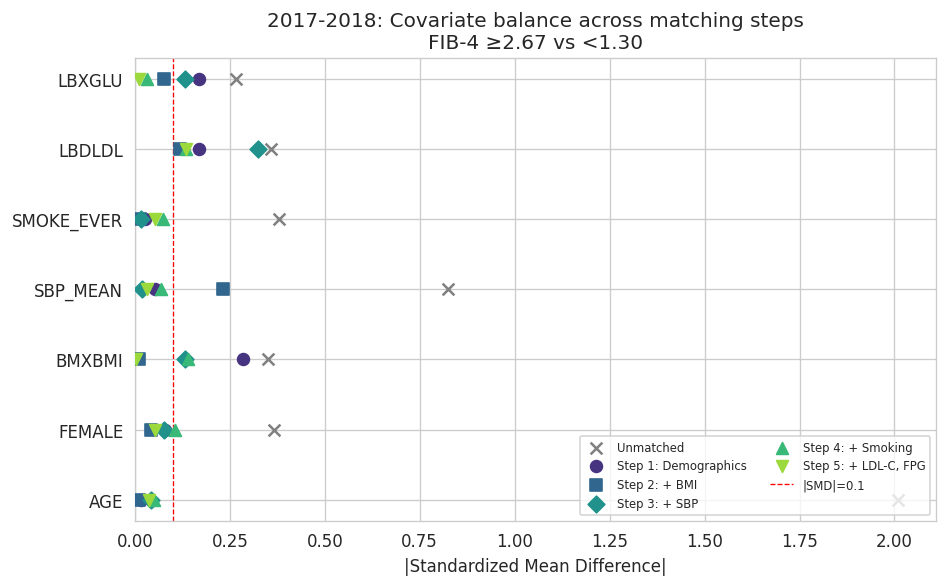

In [12]:
all_covariates = ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN', 'SMOKE_EVER', 'LBDLDL', 'LBXGLU']

for cycle in cohorts:
    fig, ax = plt.subplots(figsize=(8, 5))
    fib_col = 'FIBROSIS_FIB4'
    
    # Pre-match (crude) balance
    pre_df = cohorts[cycle][cohorts[cycle][fib_col].notna()]
    pre_bal = covariate_balance(pre_df, fib_col, all_covariates)
    y = np.arange(len(all_covariates))
    ax.scatter(pre_bal['SMD'].abs(), y, marker='x', color='gray', s=50,
               label='Unmatched', zorder=3)
    
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(MATCH_STEPS)))
    markers = ['o', 's', 'D', '^', 'v']
    
    for i, step in enumerate(MATCH_STEPS):
        key = (cycle, step['label'])
        if key not in prog_results or len(prog_results[key]['matched']) == 0:
            continue
        mdf = prog_results[key]['matched']
        bal = covariate_balance(mdf, fib_col, all_covariates)
        ax.scatter(bal['SMD'].abs(), y, marker=markers[i % len(markers)],
                   color=colors[i], s=50, label=step['label'], zorder=3)
    
    ax.axvline(0.1, color='red', ls='--', lw=0.8, label='|SMD|=0.1')
    ax.set_yticks(y)
    ax.set_yticklabels(all_covariates)
    ax.set_xlabel('|Standardized Mean Difference|')
    ax.set_title(f'{cycle}: Covariate balance across matching steps\nFIB-4 \u22652.67 vs <1.30')
    ax.legend(loc='lower right', fontsize=7, ncol=2)
    ax.set_xlim(left=0)
    plt.tight_layout()
    plt.show()

## Kaplan-Meier curves

In [13]:
def plot_km(df, fib_col, fib_label, cycle, window, title_extra=''):
    w = f'_{window}m'
    sub = df[df[fib_col].notna()].copy()
    sub['T'] = sub[f'FU{w}']
    sub['E'] = sub[f'DEATH{w}']
    
    fig, ax = plt.subplots(figsize=(7, 5))
    kmf = KaplanMeierFitter()
    
    colors = {1: '#d62728', 0: '#2ca02c'}
    labels = {1: 'Fibrosis+', 0: 'Fibrosis\u2212'}
    
    for val in [0, 1]:
        grp = sub[sub[fib_col] == val]
        if len(grp) == 0: continue
        kmf.fit(grp['T'], grp['E'],
                label=f"{labels[val]} (n={len(grp)}, d={int(grp['E'].sum())})")
        kmf.plot_survival_function(ax=ax, color=colors[val], ci_show=True, ci_alpha=0.15)
    
    g1 = sub[sub[fib_col]==1]; g0 = sub[sub[fib_col]==0]
    if len(g1)>0 and len(g0)>0 and (g1['E'].sum()+g0['E'].sum())>0:
        lr = logrank_test(g1['T'], g0['T'], g1['E'], g0['E'])
        pval = lr.p_value
        pstr = 'p < 0.001' if pval < 0.001 else f'p = {pval:.3f}'
        ax.text(0.98, 0.02, f'Log-rank {pstr}', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Months from MEC exam')
    ax.set_ylabel('Survival probability')
    ax.set_title(f'{cycle}: {fib_label}{title_extra}\n(within {window}-month window)')
    ax.set_xlim(0, window)
    ax.set_ylim(bottom=max(0, ax.get_ylim()[0] - 0.02))
    ax.legend(loc='lower left', fontsize=9)
    plt.tight_layout()
    plt.show()

### Unmatched KM curves

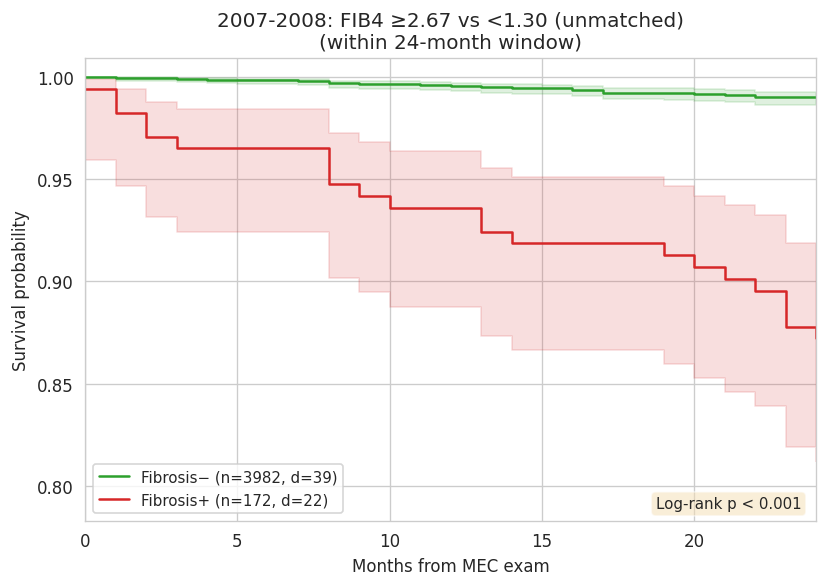

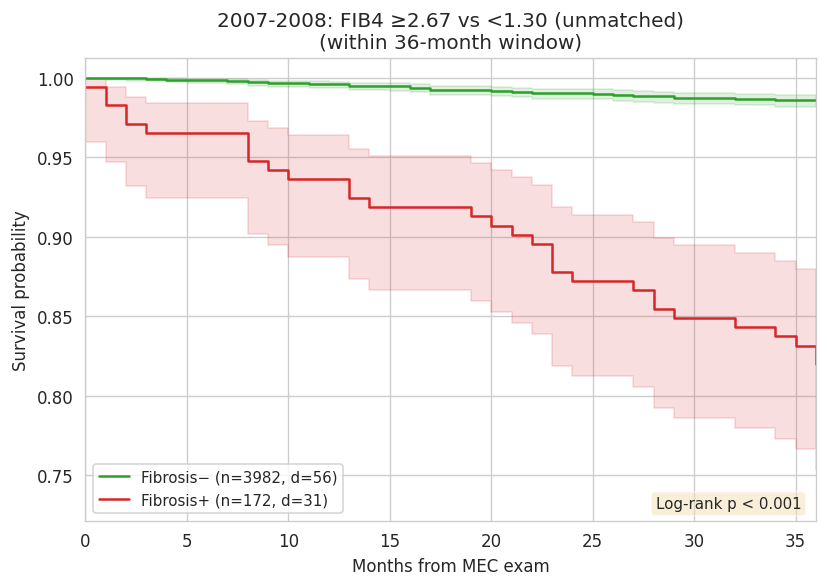

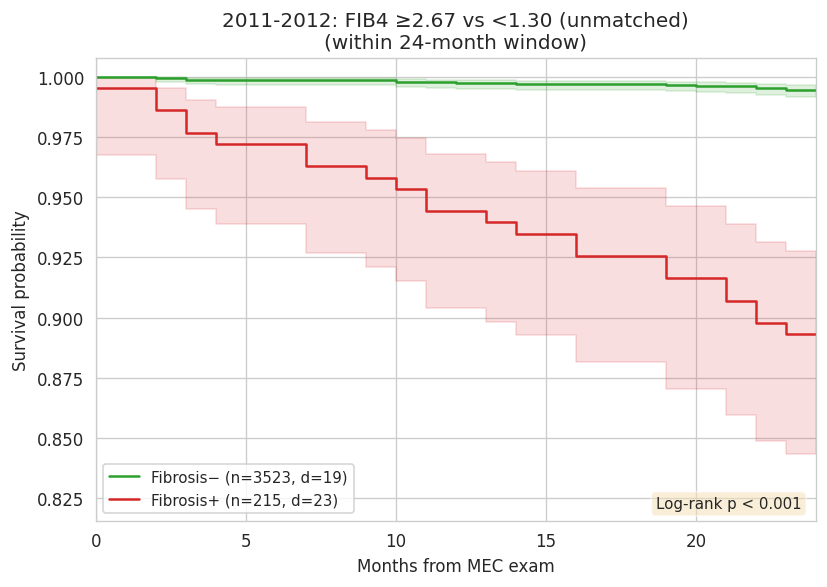

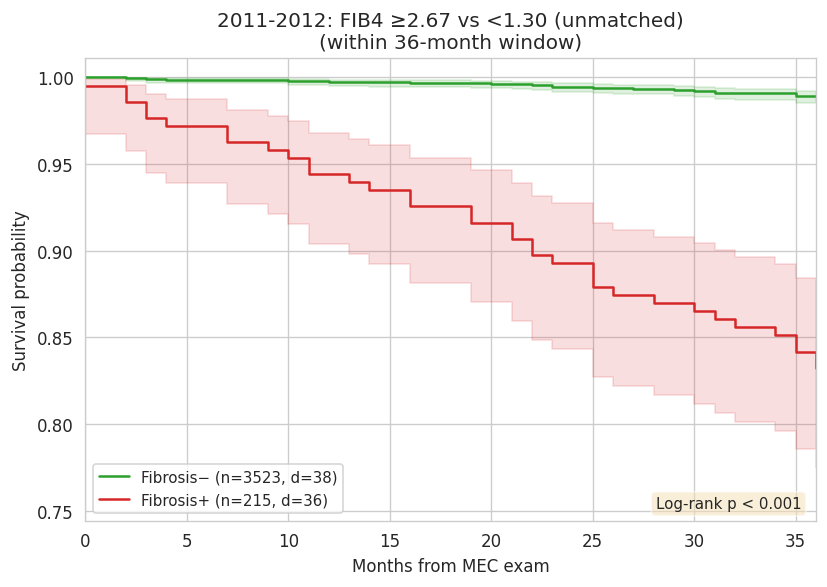

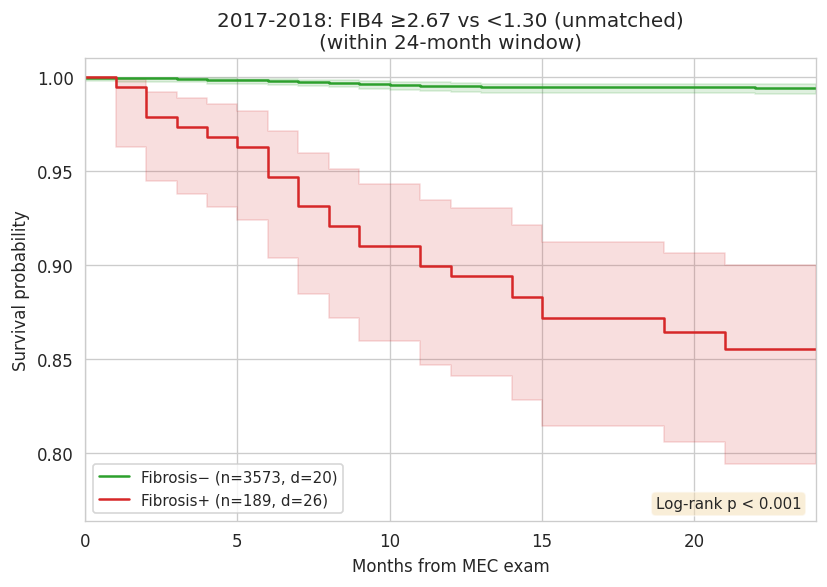

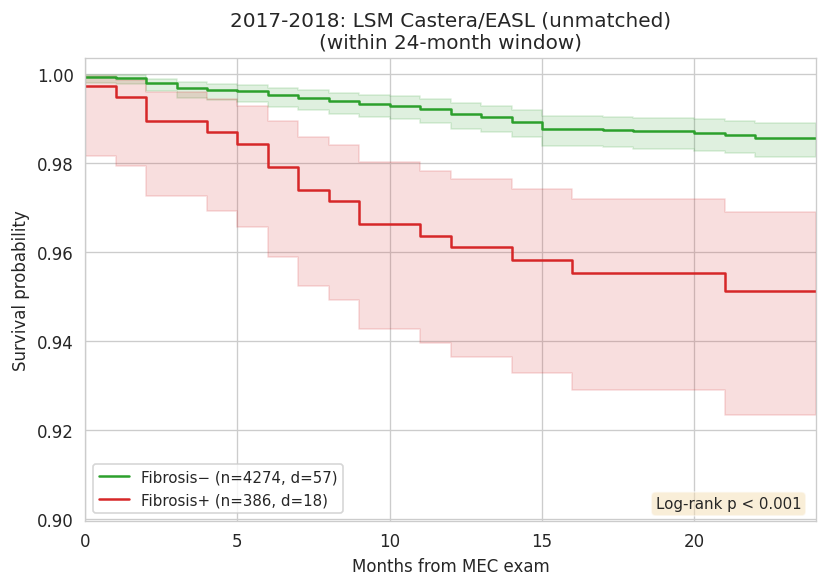

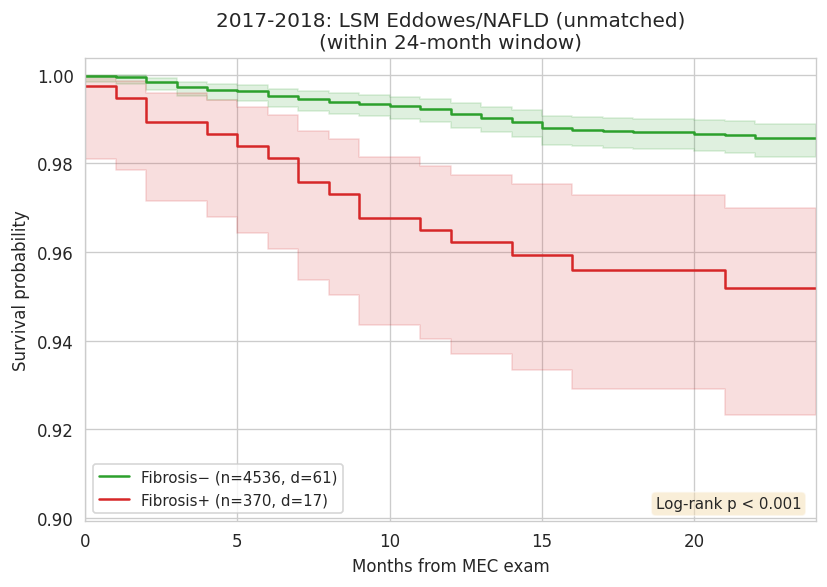

In [14]:
for cycle, df in cohorts.items():
    fib_defs = [('FIB4 \u22652.67 vs <1.30', 'FIBROSIS_FIB4')]
    if COHORT_META[cycle]['has_elast']:
        for cp in [LSM_CUTPOINTS_A, LSM_CUTPOINTS_B]:
            pfx = cp['name'].replace('/','_').replace(' ','_')
            fib_defs.append((f"LSM {cp['name']}", f'FIBROSIS_LSM_{pfx}'))
    
    windows = [WINDOW_H] + ([WINDOW_36] if cycle != '2017-2018' else [])
    for w in windows:
        for fib_label, fib_col in fib_defs:
            plot_km(df, fib_col, fib_label, cycle, w, title_extra=' (unmatched)')

### KM curves at each progressive matching step (FIB-4, 24-month window)

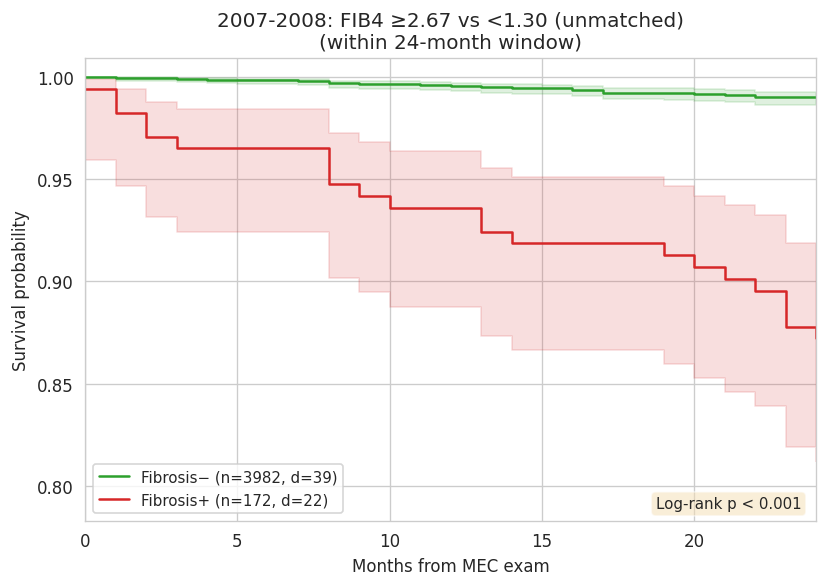

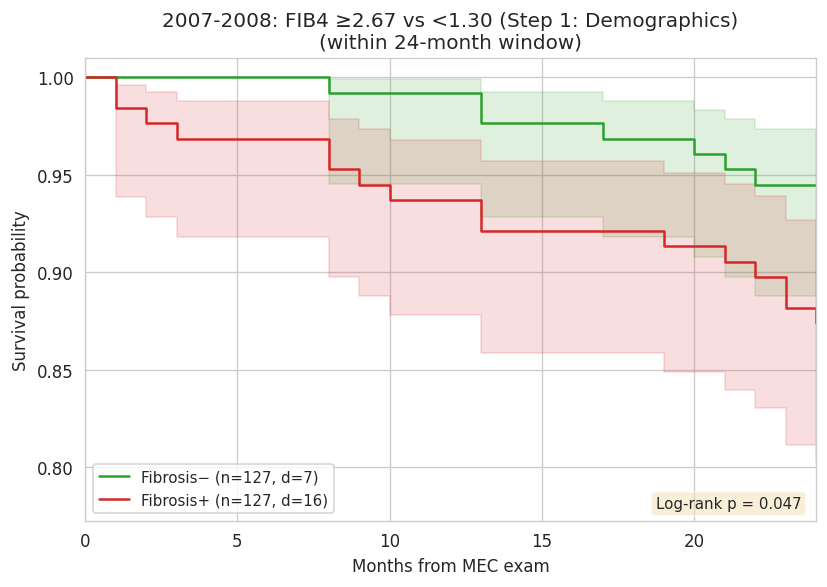

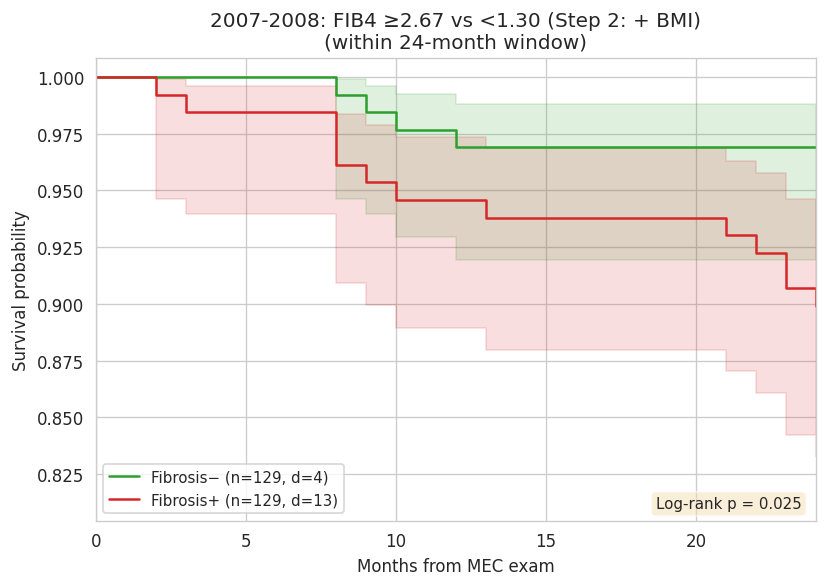

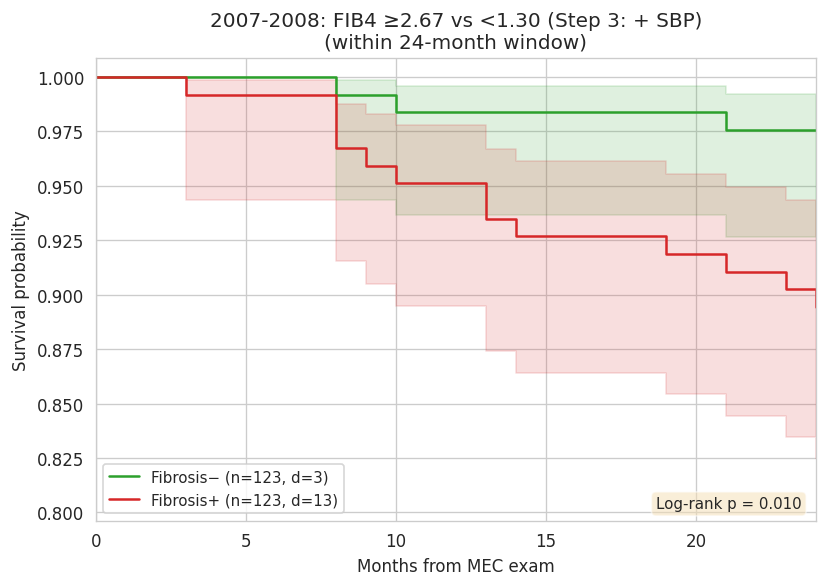

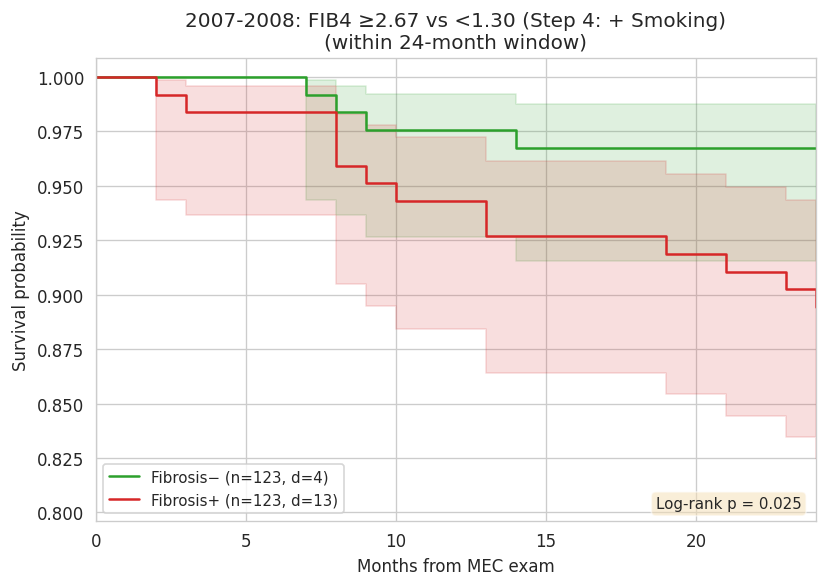

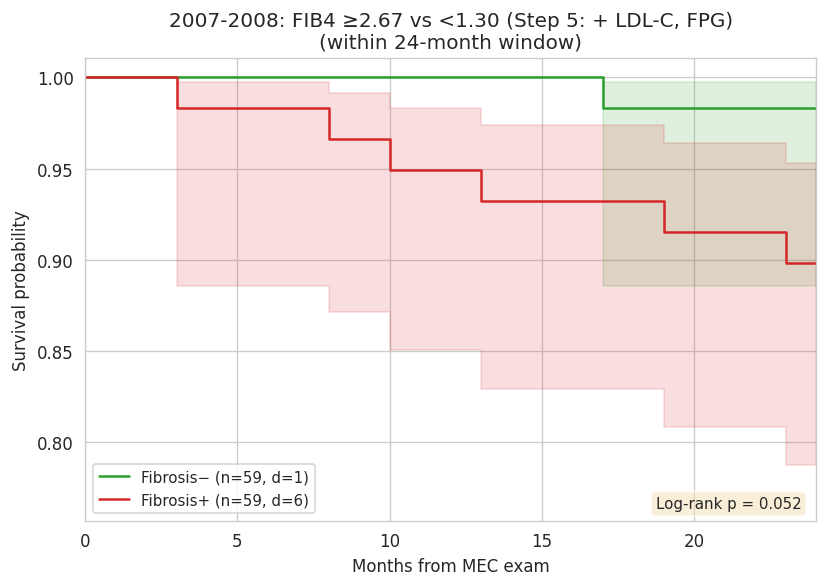

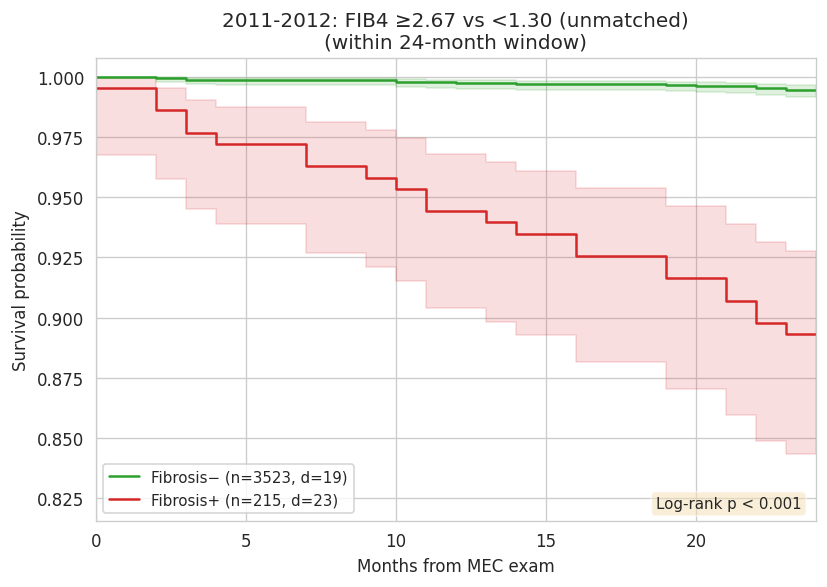

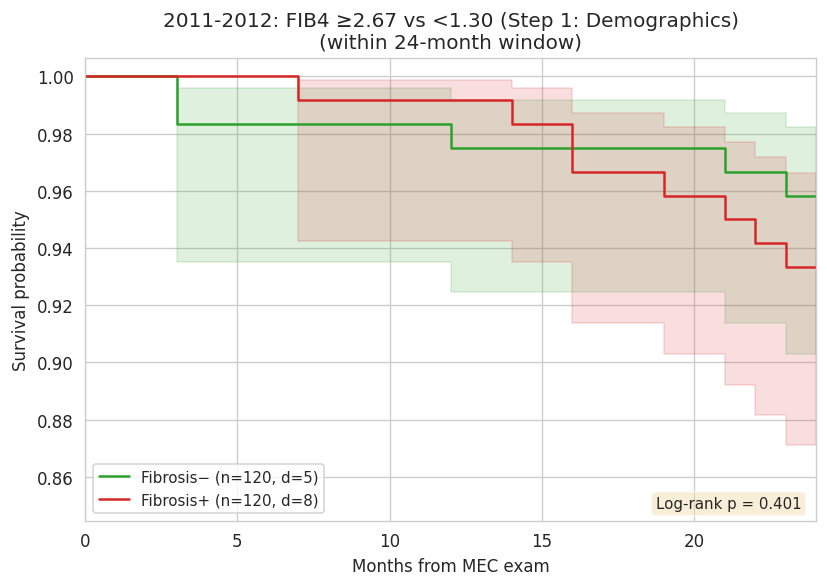

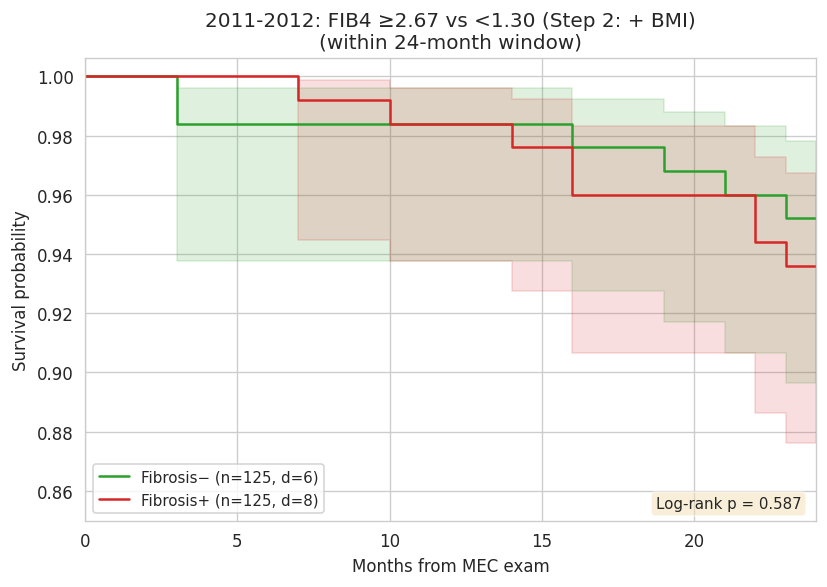

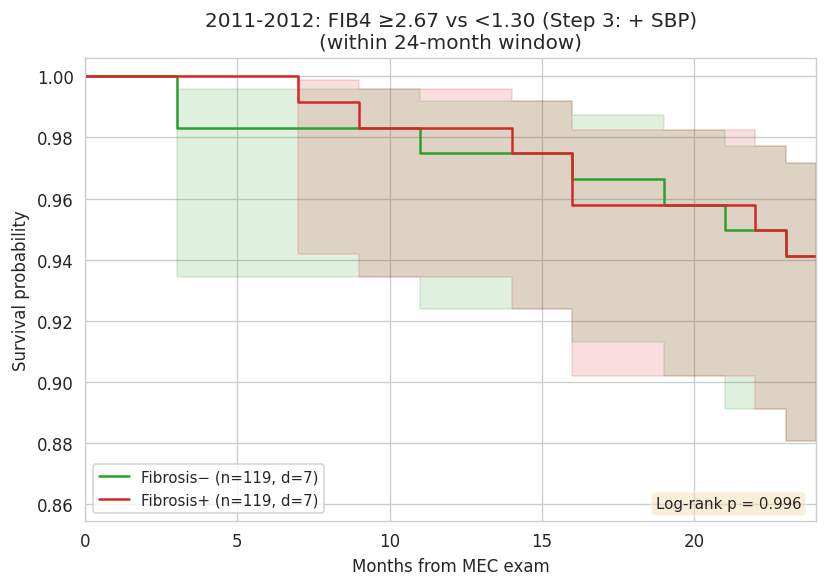

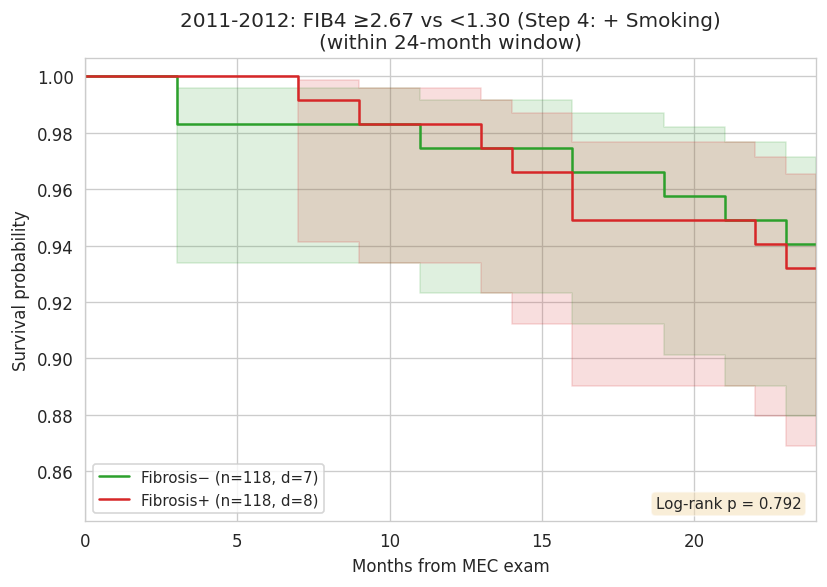

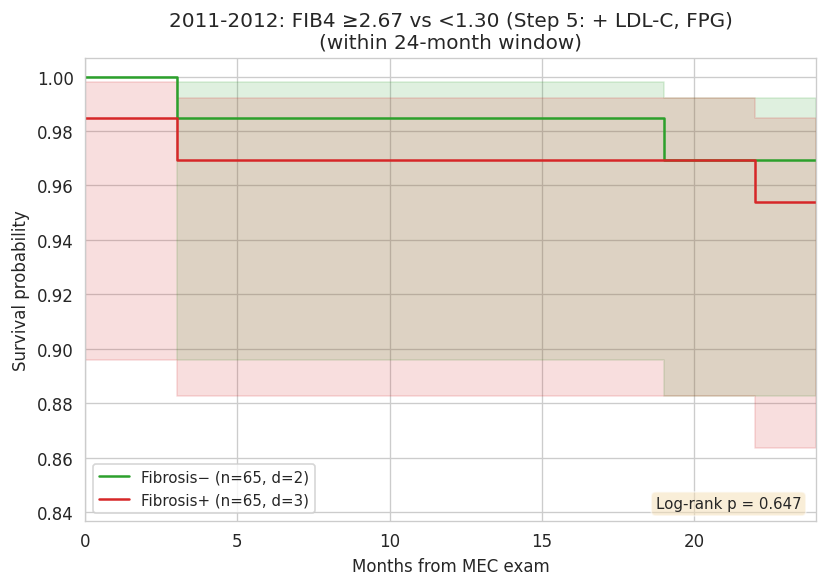

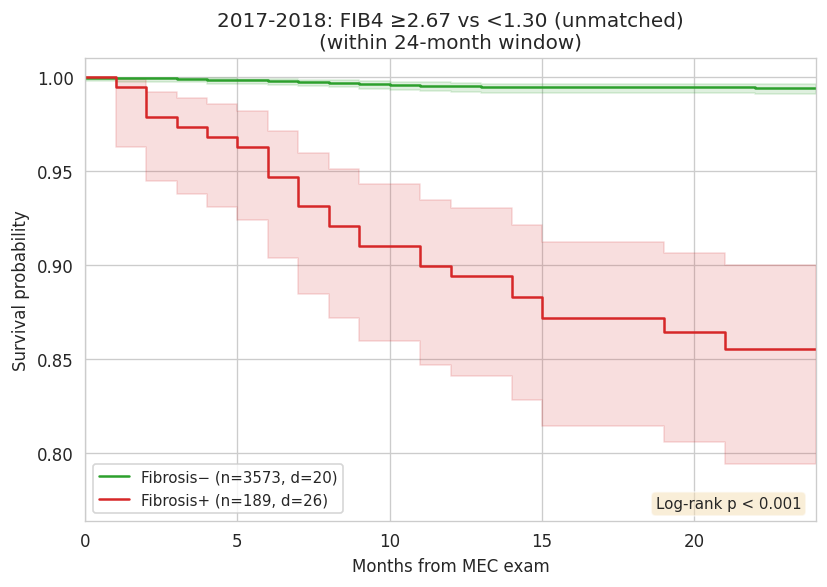

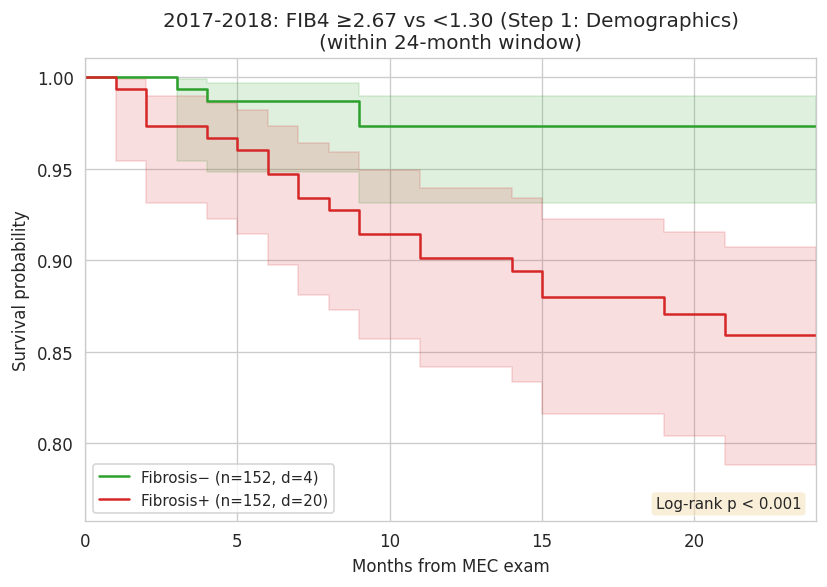

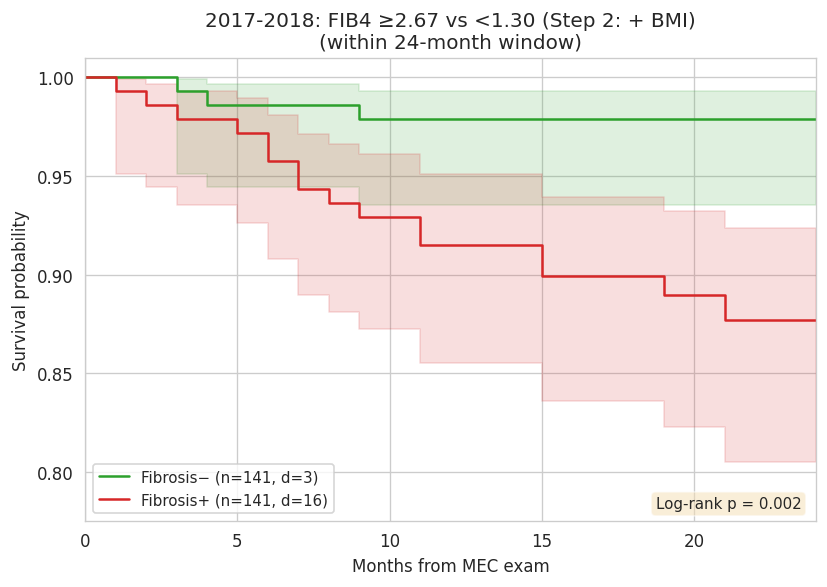

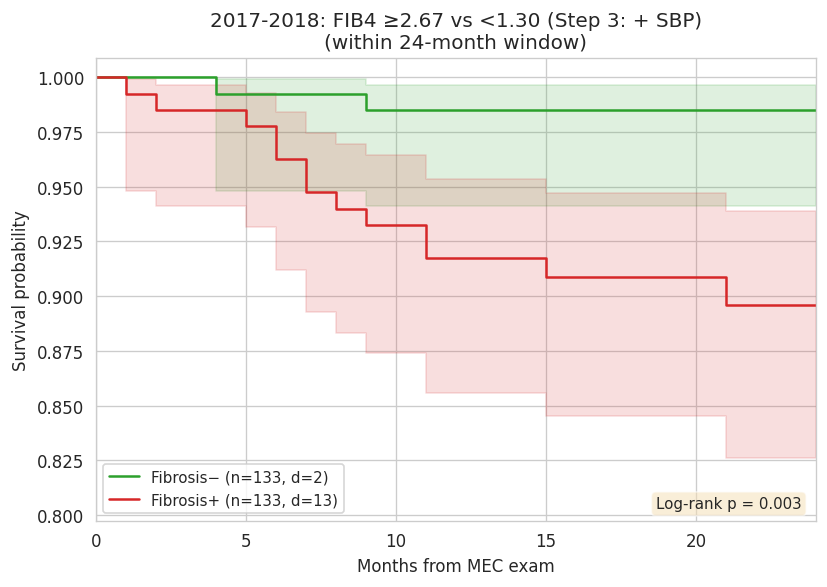

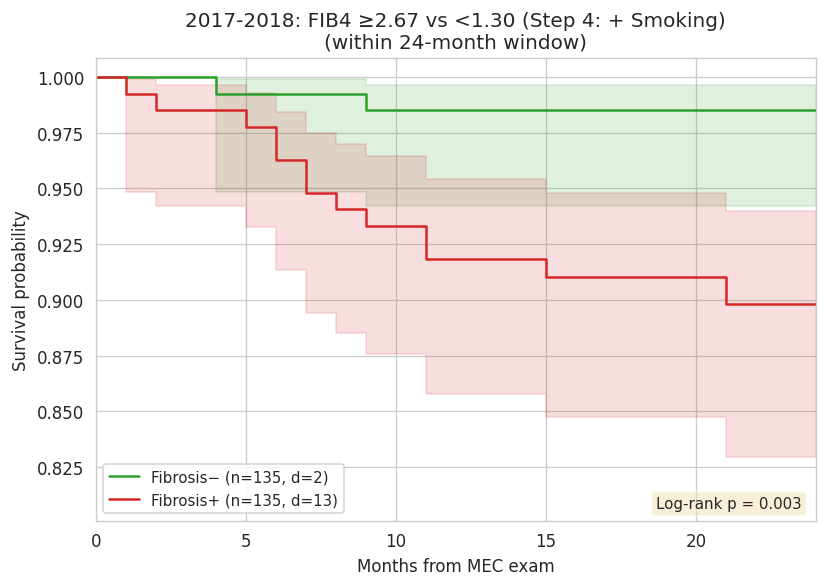

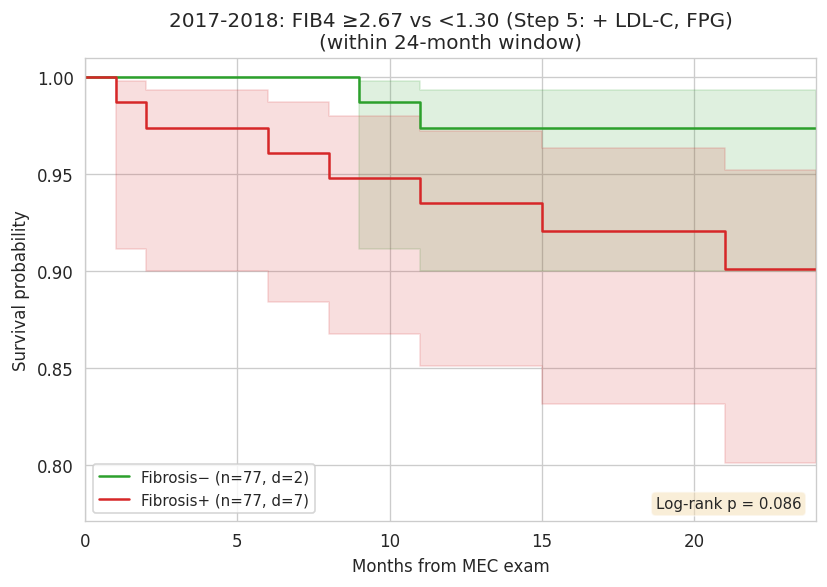

In [15]:
for cycle in cohorts:
    for step_label in ['Step 0: Crude'] + [s['label'] for s in MATCH_STEPS]:
        key = (cycle, step_label)
        if key not in prog_results:
            continue
        res = prog_results[key]
        mdf = res['matched']
        if len(mdf) == 0:
            continue
        suffix = ' (unmatched)' if step_label == 'Step 0: Crude' else f' ({step_label})'
        plot_km(mdf, res['fib_col'], 'FIB4 \u22652.67 vs <1.30', cycle, WINDOW_H,
                title_extra=suffix)

## Progressive matching for LSM definitions (2017-2018 only)

In [16]:
lsm_prog_results = {}  # (cp_name, step_label) -> same structure

df = cohorts['2017-2018']
cycle = '2017-2018'

for cp in [LSM_CUTPOINTS_A, LSM_CUTPOINTS_B]:
    pfx = cp['name'].replace('/','_').replace(' ','_')
    fib_col = f'FIBROSIS_LSM_{pfx}'
    fib_label = f"LSM {cp['name']}"
    print(f'\n{"="*60}')
    print(f'{cycle}: {fib_label} progressive matching')
    print(f'{"="*60}')
    
    # Step 0
    sub0 = df[df[fib_col].notna()].copy()
    rr0 = risk_ratio(sub0, fib_col, WINDOW_H)
    lsm_prog_results[(fib_label, 'Step 0: Crude')] = {
        'matched': sub0, 'fib_col': fib_col, 'rr': rr0,
        'n_pairs': None, 'covariates': [],
        'n_available_treated': int((sub0[fib_col]==1).sum()),
        'n_available_control': int((sub0[fib_col]==0).sum()),
    }
    print(f'  Step 0 (Crude): RR={rr0["RR"]} [{rr0["lo"]}\u2013{rr0["hi"]}]')
    
    for step in MATCH_STEPS:
        covs = step['covariates']
        label = step['label']
        print(f'\n  {label}')
        result = propensity_match(df, fib_col, covs)
        mdf, n_t, n_c = result
        if len(mdf) == 0:
            lsm_prog_results[(fib_label, label)] = {
                'matched': pd.DataFrame(), 'fib_col': fib_col, 'rr': None,
                'n_pairs': 0, 'covariates': covs,
                'n_available_treated': n_t, 'n_available_control': n_c,
            }
            continue
        mdf = add_outcomes(mdf, WINDOW_H)
        n_pairs = int((mdf[fib_col]==1).sum())
        rr = risk_ratio(mdf, fib_col, WINDOW_H)
        lsm_prog_results[(fib_label, label)] = {
            'matched': mdf, 'fib_col': fib_col, 'rr': rr,
            'n_pairs': n_pairs, 'covariates': covs,
            'n_available_treated': n_t, 'n_available_control': n_c,
        }
        print(f'    Matched {n_pairs} pairs, RR={rr["RR"]} [{rr["lo"]}\u2013{rr["hi"]}]')


2017-2018: LSM Castera/EASL progressive matching
  Step 0 (Crude): RR=3.5 [2.08–5.88]

  Step 1: Demographics
    Matched 386 pairs, RR=18.0 [2.41–134.17]

  Step 2: + BMI


    Matched 349 pairs, RR=3.5 [1.16–10.53]

  Step 3: + SBP
    Matched 332 pairs, RR=3.0 [1.1–8.16]

  Step 4: + Smoking


    Matched 333 pairs, RR=3.0 [1.1–8.16]

  Step 5: + LDL-C, FPG
    Matched 136 pairs, RR=1.33 [0.3–5.85]

2017-2018: LSM Eddowes/NAFLD progressive matching
  Step 0 (Crude): RR=3.42 [2.02–5.79]

  Step 1: Demographics


    Matched 370 pairs, RR=17.0 [2.27–127.09]

  Step 2: + BMI
    Matched 342 pairs, RR=1.86 [0.75–4.6]

  Step 3: + SBP


    Matched 327 pairs, RR=3.5 [1.16–10.52]

  Step 4: + Smoking
    Matched 329 pairs, RR=2.8 [1.02–7.68]

  Step 5: + LDL-C, FPG
    Matched 137 pairs, RR=nan [nan–nan]


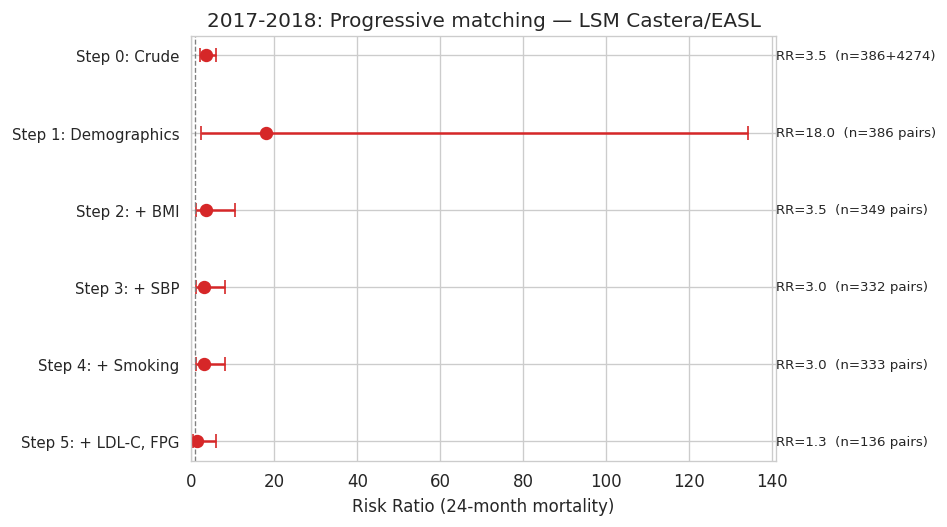

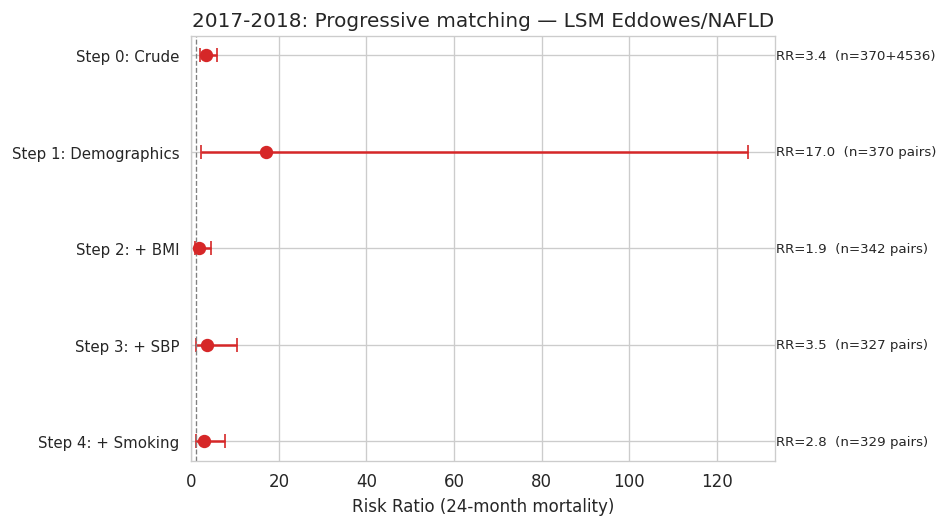

In [17]:
# Forest plots for LSM definitions
step_order = ['Step 0: Crude'] + [s['label'] for s in MATCH_STEPS]

for cp in [LSM_CUTPOINTS_A, LSM_CUTPOINTS_B]:
    fib_label = f"LSM {cp['name']}"
    fig, ax = plt.subplots(figsize=(8, 4.5))
    
    y_labels, rrs, los, his, ns = [], [], [], [], []
    for label in step_order:
        key = (fib_label, label)
        if key not in lsm_prog_results:
            continue
        res = lsm_prog_results[key]
        rr = res['rr']
        if rr is None or pd.isna(rr['RR']):
            continue
        y_labels.append(label)
        rrs.append(rr['RR'])
        los.append(rr['lo'])
        his.append(rr['hi'])
        n = res['n_pairs']
        ns.append(f'n={n} pairs' if n is not None else
                  f"n={res['n_available_treated']}+{res['n_available_control']}")
    
    if not rrs:
        continue
    
    y_pos = np.arange(len(y_labels))
    ax.errorbar(rrs, y_pos,
                xerr=[np.array(rrs)-np.array(los), np.array(his)-np.array(rrs)],
                fmt='o', color='#d62728', capsize=4, markersize=7, lw=1.5)
    ax.axvline(1.0, color='gray', ls='--', lw=0.8)
    
    for i, (rr_val, n_lab) in enumerate(zip(rrs, ns)):
        ax.text(max(his) * 1.05, i, f'RR={rr_val:.1f}  ({n_lab})', va='center', fontsize=8)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Risk Ratio (24-month mortality)')
    ax.set_title(f'2017-2018: Progressive matching — {fib_label}')
    ax.set_xlim(left=0)
    plt.tight_layout()
    plt.show()

## Bar plots: all-cause and cause-group mortality (unmatched)

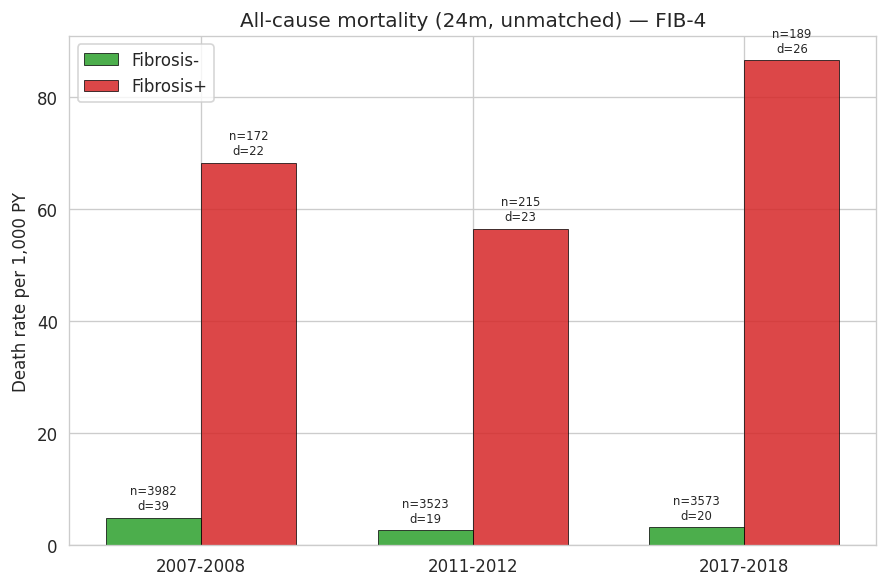

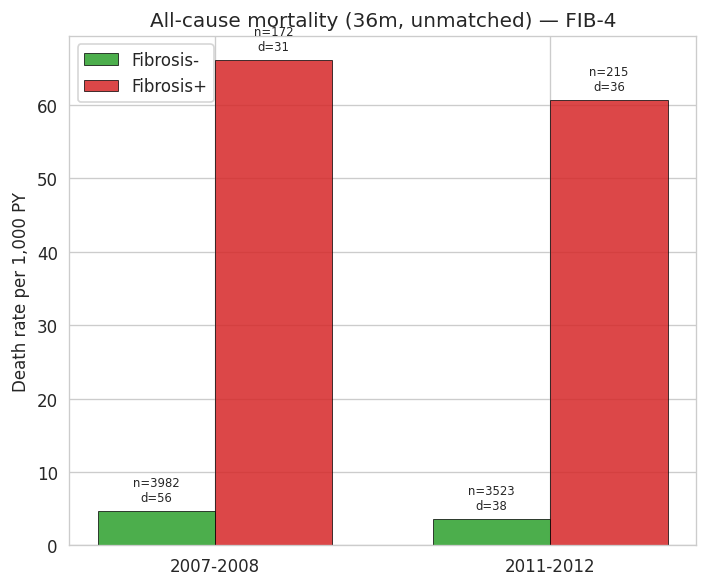

In [18]:
def plot_allcause_comparison(rdf, title):
    sub = rdf[rdf['Def'].str.contains('FIB4')].copy()
    if len(sub) == 0: return
    cycles = sub['Cycle'].unique()
    fig, ax = plt.subplots(figsize=(max(6, len(cycles)*2.5), 5))
    x = np.arange(len(cycles))
    w = 0.35
    for i, (grp, color) in enumerate([('Fibrosis-','#2ca02c'),('Fibrosis+','#d62728')]):
        vals, annots = [], []
        for cyc in cycles:
            row = sub[(sub['Cycle']==cyc) & (sub['Group']==grp)]
            if len(row):
                vals.append(row.iloc[0]['Rate/1000PY'])
                annots.append(f"n={row.iloc[0]['N']}\nd={int(row.iloc[0]['Deaths'])}")
            else:
                vals.append(0); annots.append('')
        offset = -w/2 + i*w
        bars = ax.bar(x+offset, vals, w, label=grp, color=color,
                       edgecolor='black', lw=0.5, alpha=0.85)
        for j, (v, a) in enumerate(zip(vals, annots)):
            ax.text(x[j]+offset, v+1, a, ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(cycles)
    ax.set_ylabel('Death rate per 1,000 PY')
    ax.set_title(title); ax.legend(); ax.set_ylim(bottom=0)
    plt.tight_layout(); plt.show()

for w in [WINDOW_H, WINDOW_36]:
    sub = rates_df[rates_df['Window']==w]
    if len(sub) > 0:
        plot_allcause_comparison(sub, f'All-cause mortality ({w}m, unmatched) \u2014 FIB-4')

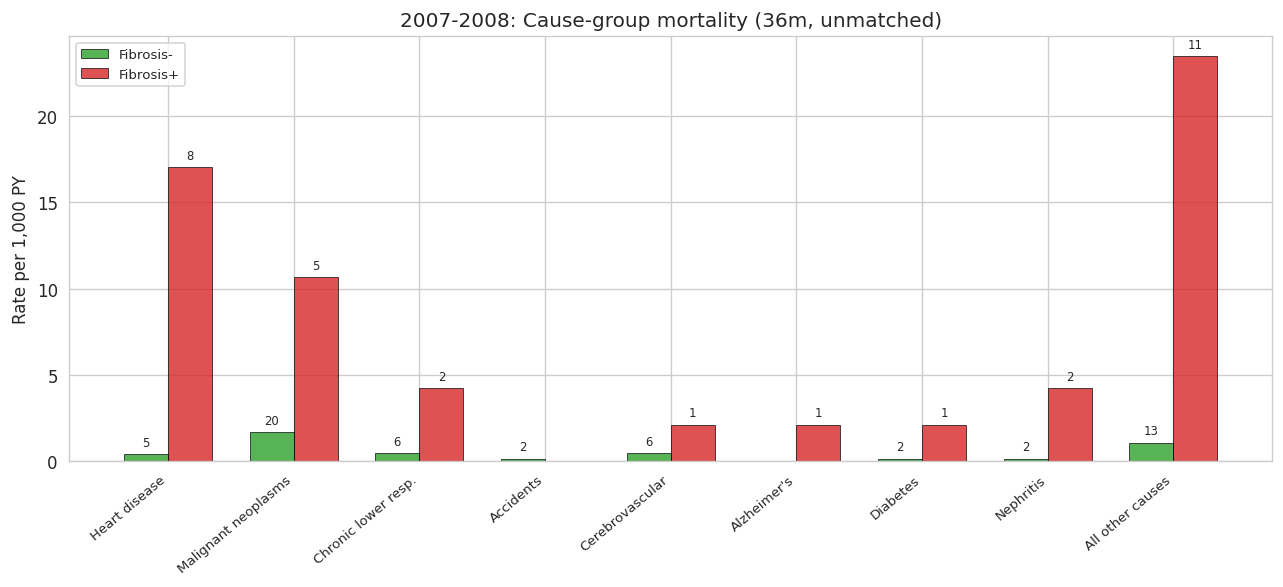

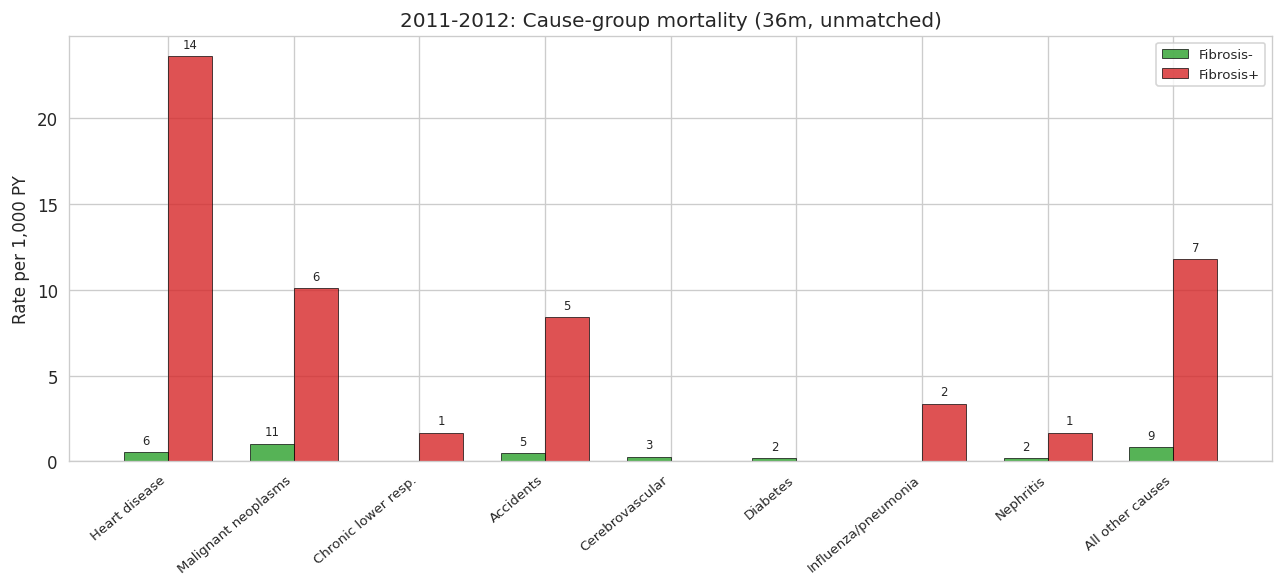

In [19]:
def plot_causegroup(rdf, cycle, window, fib_label, title):
    sub = rdf[(rdf['Cycle']==cycle) & (rdf['Window']==window) &
              (rdf['Def'].str.contains(fib_label.split()[0]))]
    if len(sub)==0: return
    dcols = [c for c in sub.columns if c.startswith('d_')]
    active = [c for c in dcols if sub[c].sum()>0]
    if not active: return
    fig, ax = plt.subplots(figsize=(max(7, len(active)*1.2), 5))
    x = np.arange(len(active))
    w = 0.35
    for i, (grp, color) in enumerate([('Fibrosis-','#2ca02c'),('Fibrosis+','#d62728')]):
        row = sub[sub['Group']==grp]
        if len(row)==0: continue
        row = row.iloc[0]
        py = row['PY']
        vals = [row[c]/py*1000 if py>0 else 0 for c in active]
        cnts = [int(row[c]) for c in active]
        offset = -w/2 + i*w
        ax.bar(x+offset, vals, w, label=grp, color=color,
               edgecolor='black', lw=0.5, alpha=0.8)
        for j, (v,c) in enumerate(zip(vals,cnts)):
            if c>0: ax.text(x[j]+offset, v+0.3, str(c), ha='center', va='bottom', fontsize=7)
    labels = [c.replace('d_','') for c in active]
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('Rate per 1,000 PY')
    ax.set_title(title); ax.legend(fontsize=8); ax.set_ylim(bottom=0)
    plt.tight_layout(); plt.show()

for cycle in ['2007-2008', '2011-2012']:
    plot_causegroup(rates_df, cycle, WINDOW_36, 'FIB4',
                    f'{cycle}: Cause-group mortality (36m, unmatched)')

## Summary tables (CSV export)

In [20]:
os.makedirs('outputs/tables', exist_ok=True)

cards_df.to_csv('outputs/tables/cohort_card_by_cohort.csv', index=False)
rates_df.to_csv('outputs/tables/mortality_allcause_by_cohort_window_fibrosisdef.csv', index=False)
prog_summary.to_csv('outputs/tables/progressive_matching_summary.csv', index=False)

# Cause-group long table
cg_rows = []
for _, row in rates_df.iterrows():
    for code, lab in UCOD_LABELS.items():
        dc = f'd_{lab}'
        if dc in row and pd.notna(row[dc]):
            cg_rows.append({
                'Cycle':row['Cycle'], 'Window':row['Window'], 'Def':row['Def'],
                'Group':row['Group'], 'N':row['N'], 'PY':row['PY'],
                'UCOD':code, 'Cause':lab, 'Deaths':int(row[dc]),
                'Rate/1000PY':round(row[dc]/row['PY']*1000,1) if row['PY']>0 else np.nan,
                'Flag': 'UNSTABLE' if row[dc]<10 else '',
            })
if cg_rows:
    pd.DataFrame(cg_rows).to_csv(
        'outputs/tables/mortality_causegroup_by_cohort_window_fibrosisdef.csv', index=False)

print('Tables saved to outputs/tables/')
for f in sorted(os.listdir('outputs/tables')):
    print(f'  {f}')

Tables saved to outputs/tables/
  cohort_card_by_cohort.csv
  effect_estimates_matched.csv
  mortality_allcause_by_cohort_window_fibrosisdef.csv
  mortality_causegroup_by_cohort_window_fibrosisdef.csv
  mortality_matched_by_cohort_window_fibrosisdef.csv
  progressive_matching_summary.csv


## Cohort summary

In [21]:
summary = """
### Cohort selection rationale

| Cohort | Max FU (months) | % \u226536m | % \u226524m | UCOD detail | Elastography |
|--------|----------------|--------|--------|-------------|-------------|
| 2007-2008 | ~159 | ~96% | ~98% | Full (10 groups) | No |
| 2011-2012 | ~113 | ~97% | ~98% | Full (10 groups) | No |
| 2017-2018 | ~37  | ~2%  | ~51% | Coarsened (3 groups) | Yes (VCTE) |

### Key findings

**Unmatched analysis:**
- FIB-4-defined fibrosis consistently associated with 13\u201325\u00d7 higher crude mortality
- LSM-based fibrosis (2017-2018) shows ~3.5\u00d7 crude risk ratio

**Progressive matching reveals confounding structure:**
- Matching on age+sex produces the largest attenuation (crude RR ~13\u201325\u00d7 drops to ~3\u20136\u00d7),
  consistent with age being embedded in the FIB-4 formula
- Adding BMI, SBP, and smoking produces modest further attenuation
- Adding fasting-subsample variables (LDL-C, FPG) restricts the sample to ~\u2153 of participants;
  the RR estimate changes but wider CIs reflect the loss of power
- After full matching, fibrosis remains associated with elevated mortality (RR > 1),
  though small matched samples yield wide confidence intervals

### Limitations
1. **Fibrosis is proxy-defined** \u2014 FIB-4 and LSM are not histological diagnoses
2. **FIB-4 includes age** \u2014 crude RR overstates the association; matched/adjusted estimates more reliable
3. **Public-use COD coarsening** \u2014 Only 3 UCOD groups available for 2017-2018
4. **Short follow-up** for 2017-2018 (~51% have \u226524 months)
5. **Fasting subsample** \u2014 LDL-C and FPG restrict matching to ~\u2153 of the cohort
6. **Small matched samples** \u2014 Many cells have <10 events
7. **No survey weights** \u2014 Unweighted estimates; not nationally representative
"""

display(Markdown(summary))

with open('outputs/cohort_summary.md', 'w') as f:
    f.write('# NHANES Mortality by Liver Fibrosis Status\n')
    f.write(summary)
print('Saved: outputs/cohort_summary.md')


### Cohort selection rationale

| Cohort | Max FU (months) | % ≥36m | % ≥24m | UCOD detail | Elastography |
|--------|----------------|--------|--------|-------------|-------------|
| 2007-2008 | ~159 | ~96% | ~98% | Full (10 groups) | No |
| 2011-2012 | ~113 | ~97% | ~98% | Full (10 groups) | No |
| 2017-2018 | ~37  | ~2%  | ~51% | Coarsened (3 groups) | Yes (VCTE) |

### Key findings

**Unmatched analysis:**
- FIB-4-defined fibrosis consistently associated with 13–25× higher crude mortality
- LSM-based fibrosis (2017-2018) shows ~3.5× crude risk ratio

**Progressive matching reveals confounding structure:**
- Matching on age+sex produces the largest attenuation (crude RR ~13–25× drops to ~3–6×),
  consistent with age being embedded in the FIB-4 formula
- Adding BMI, SBP, and smoking produces modest further attenuation
- Adding fasting-subsample variables (LDL-C, FPG) restricts the sample to ~⅓ of participants;
  the RR estimate changes but wider CIs reflect the loss of power
- After full matching, fibrosis remains associated with elevated mortality (RR > 1),
  though small matched samples yield wide confidence intervals

### Limitations
1. **Fibrosis is proxy-defined** — FIB-4 and LSM are not histological diagnoses
2. **FIB-4 includes age** — crude RR overstates the association; matched/adjusted estimates more reliable
3. **Public-use COD coarsening** — Only 3 UCOD groups available for 2017-2018
4. **Short follow-up** for 2017-2018 (~51% have ≥24 months)
5. **Fasting subsample** — LDL-C and FPG restrict matching to ~⅓ of the cohort
6. **Small matched samples** — Many cells have <10 events
7. **No survey weights** — Unweighted estimates; not nationally representative


Saved: outputs/cohort_summary.md
